In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

| Column | Description |
|--------|-------------|
| **CUST_ID** | Identification of Credit Card holder *(Categorical)* |
| **BALANCE** | Balance amount left in their account to make purchases |
| **BALANCE_FREQUENCY** | How frequently the Balance is updated, score between 0 and 1 *(1 = frequently updated, 0 = not frequently updated)* |
| **PURCHASES** | Amount of purchases made from account |
| **ONEOFF_PURCHASES** | Maximum purchase amount done in one-go |
| **INSTALLMENTS_PURCHASES** | Amount of purchase done in installment |
| **CASH_ADVANCE** | Cash in advance given by the user |
| **PURCHASES_FREQUENCY** | How frequently the Purchases are being made, score between 0 and 1 *(1 = frequently purchased, 0 = not frequently purchased)* |
| **ONEOFFPURCHASESFREQUENCY** | How frequently Purchases are happening in one-go *(1 = frequently purchased, 0 = not frequently purchased)* |
| **PURCHASESINSTALLMENTSFREQUENCY** | How frequently purchases in installments are being done *(1 = frequently done, 0 = not frequently done)* |
| **CASHADVANCEFREQUENCY** | How frequently the cash in advance being paid |
| **CASHADVANCETRX** | Number of Transactions made with "Cash in Advanced" |
| **PURCHASES_TRX** | Number of purchase transactions made |
| **CREDIT_LIMIT** | Limit of Credit Card for user |
| **PAYMENTS** | Amount of Payment done by user |
| **MINIMUM_PAYMENTS** | Minimum amount of payments made by user |
| **PRCFULLPAYMENT** | Percent of full payment paid by user |
| **TENURE** | Tenure of credit card service for user |

In [2]:
df = pd.read_csv('/kaggle/input/datasets/arjunbhasin2013/ccdata/CC GENERAL.csv')

# EDA

In [3]:
df['BALANCE_FREQUENCY'].value_counts()

BALANCE_FREQUENCY
1.000000    6211
0.909091     410
0.818182     278
0.727273     223
0.545455     219
0.636364     209
0.454545     172
0.363636     170
0.272727     151
0.181818     146
0.000000      80
0.090909      67
0.833333      60
0.875000      57
0.900000      55
0.888889      53
0.857143      51
0.500000      40
0.666667      37
0.777778      22
0.333333      22
0.800000      20
0.571429      19
0.750000      17
0.714286      15
0.700000      13
0.625000      11
0.400000      10
0.555556      10
0.125000       9
0.300000       9
0.375000       9
0.200000       9
0.285714       8
0.250000       8
0.100000       8
0.166667       7
0.142857       7
0.444444       7
0.600000       6
0.222222       5
0.111111       5
0.428571       5
Name: count, dtype: int64

`BALANCE_FREQUENCY` this column has some noise, so we will change it to have only 10 numers .1, .2, .3, ..., 1

In [4]:
df['BALANCE_FREQUENCY'] = np.floor(df['BALANCE_FREQUENCY'] * 10) / 10
percentage_series = df['BALANCE_FREQUENCY'].value_counts().sort_index() * 100.0 / len(df['BALANCE_FREQUENCY'])
percentage_series.name = 'PERCENT'
percentage_series

BALANCE_FREQUENCY
0.0     1.642458
0.1     2.033520
0.2     2.022346
0.3     2.346369
0.4     2.167598
0.5     3.217877
0.6     2.938547
0.7     3.240223
0.8     5.798883
0.9     5.195531
1.0    69.396648
Name: PERCENT, dtype: float64

In [5]:
(df['BALANCE_FREQUENCY'] > 0).sum()*100.0/len(df['BALANCE_FREQUENCY'])

np.float64(98.35754189944134)

there are **98.35%** active users from all users <br>
**1.65%** out of all users are non-active users

In [6]:
non_active_users_purchases = df[df['BALANCE_FREQUENCY']==0]['PURCHASES']

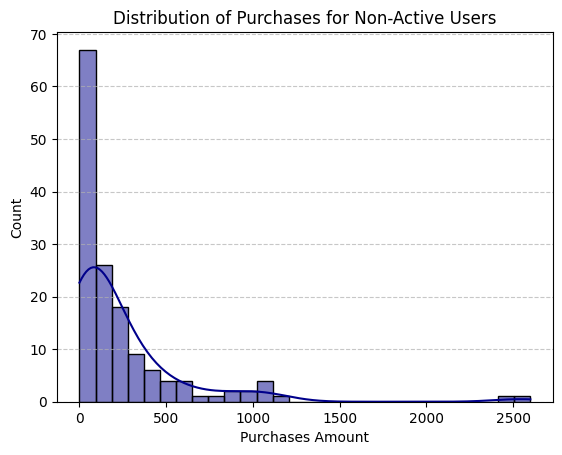

In [7]:
sns.histplot(x=non_active_users_purchases, kde=True, color='darkblue')
plt.title('Distribution of Purchases for Non-Active Users')
plt.xlabel('Purchases Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

from the above distribution we see that non-active users have purchased!!

In [8]:
(non_active_users_purchases).sum()

np.float64(35312.3)

here we have a quesiton how non-active users (balance doesn't change in the past 6 months) and they have some purchases? <br>

In [9]:
df[df['BALANCE_FREQUENCY']==0]['BALANCE']

63       7.152356
99       0.000000
103      0.624240
129     69.405545
181      0.000000
          ...    
8622     0.065402
8721     4.843351
8751     0.546067
8753     0.223351
8755     3.036243
Name: BALANCE, Length: 147, dtype: float64

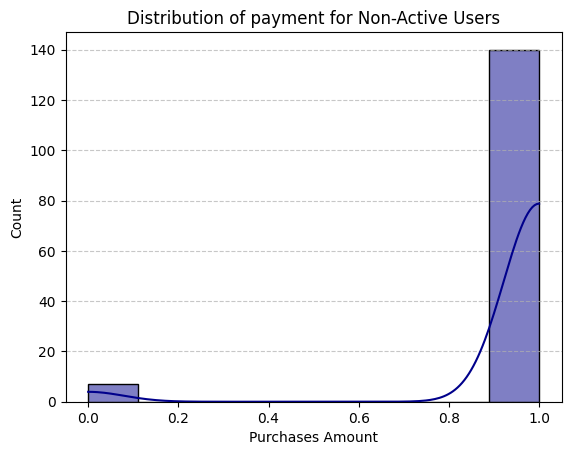

In [10]:
non_active_users_payments = df[df['BALANCE_FREQUENCY']==0]['PAYMENTS']<4000
sns.histplot(x=non_active_users_payments, kde=True, color='darkblue')
plt.title('Distribution of payment for Non-Active Users')
plt.xlabel('Purchases Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

there is an indicator that there are equal sizes, which indicate that all of them paid their purchases

In [11]:
non_active_df = df[df['BALANCE_FREQUENCY']==0]


In [12]:
print((non_active_df['BALANCE']!=0).sum())
print((non_active_df['BALANCE']==0).sum())

67
80


now we have a quesiton did they pay for these purchases that were before 6 months? <br>
* Number of people that didn't pay for their purchases **67**
* Number of people that paid their purchases **80**


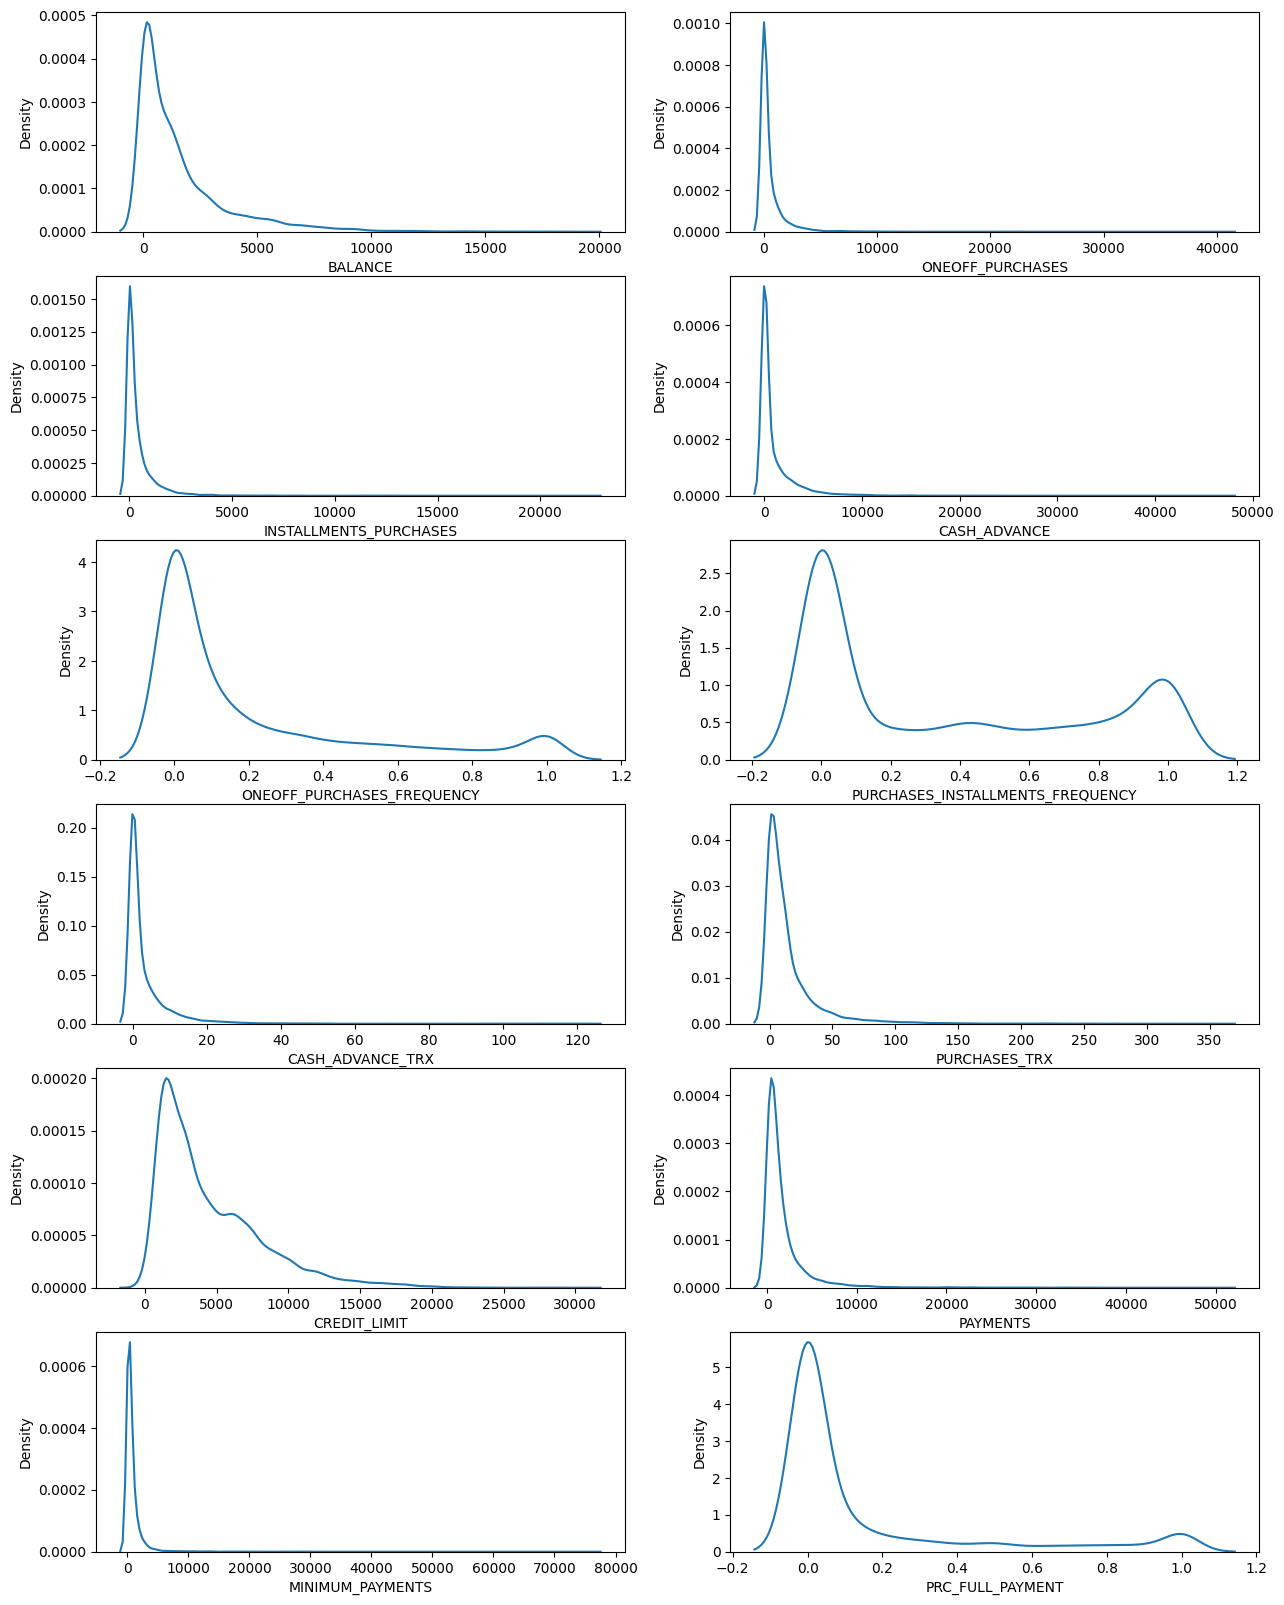

In [13]:
plt.figure(figsize=(15,20))
cols = ['BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
        'ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_TRX',
        'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS','PRC_FULL_PAYMENT']
for i, col in enumerate(cols):
    ax = plt.subplot(6, 2, i+1)
    sns.kdeplot(df[col], ax=ax)
plt.show()

In [14]:
df[['PRC_FULL_PAYMENT']].value_counts(normalize=True)*100

PRC_FULL_PAYMENT
0.000000            65.955307
1.000000             5.452514
0.083333             4.759777
0.166667             1.854749
0.250000             1.743017
0.500000             1.743017
0.090909             1.709497
0.333333             1.497207
0.100000             1.050279
0.200000             0.927374
0.666667             0.871508
0.916667             0.860335
0.181818             0.837989
0.750000             0.759777
0.833333             0.703911
0.111111             0.681564
0.142857             0.603352
0.125000             0.581006
0.416667             0.491620
0.400000             0.469274
0.300000             0.446927
0.454545             0.402235
0.272727             0.391061
0.800000             0.368715
0.363636             0.357542
0.583333             0.346369
0.600000             0.312849
0.545455             0.301676
0.636364             0.290503
0.285714             0.268156
0.727273             0.245810
0.222222             0.223464
0.909091             0.

around **66%** of the users are slow payer <br>
from that column we could divide them into 2 groups fast or slow payer

# Experminment

now i want to merge some columns with each other <br>
`PURCHASES` + `CASH_ADVANCE` = `TOTAL_SPEND` <br>
`PURCHASES_TRX` + `CASH_ADVANCE_TRX` = `TOTAL_TRX` <br>
`BALANCE` / `CREDIT_LIMIT` = `CREDIT_UTILIZATION` <br>
`ONEOFF_PURCHASES` / `PURCHASES` = `ONEOFF_RATIO` <br>
`INSTALLMENTS_PURCHASES` / `PURCHASES` = `INSTALLMENT_RATIO` <br>
`PAYMENTS` / `BALANCE` = `PAY_BALANCE_RATIO` <br>

`BALANCE` / `TOTAL_SPEND` = `DEBT_BURDEN`

 Tried but their output wasn't good! 😥

# Handling NULL

###  MINIMUM_PAYMENTS NULLs

In [15]:
null_data = df[df['MINIMUM_PAYMENTS'].isna()]

In [16]:
len(null_data)

313

In [17]:
null_data.sample(5)[['BALANCE','PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT']]

,BALANCE,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
353,36.567901,0.0,NaN,0.0
1819,1.420316,0.0,NaN,0.0
654,0.000000,0.0,NaN,0.0
183,5.465999,0.0,NaN,0.0
111,3393.351236,0.0,NaN,0.0


In [18]:
df[(df['MINIMUM_PAYMENTS'].isna())][['BALANCE','BALANCE_FREQUENCY','CASH_ADVANCE','PURCHASES','PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT']]

,BALANCE,BALANCE_FREQUENCY,CASH_ADVANCE,PURCHASES,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
3,1666.670542,0.6,205.788017,1499.00,0.000000,NaN,0.0
45,2242.311686,1.0,184.648692,437.00,0.000000,NaN,0.0
47,3910.111237,1.0,1980.873201,0.00,0.000000,NaN,0.0
54,6.660517,0.6,0.000000,310.00,417.016763,NaN,0.0
55,1311.995984,1.0,0.000000,1283.90,0.000000,NaN,0.0
...,...,...,...,...,...,...,...
8919,14.524779,0.3,0.000000,152.00,0.000000,NaN,0.0
8929,371.527312,0.3,1465.407927,0.00,0.000000,NaN,0.0
8935,183.817004,1.0,0.000000,465.90,0.000000,NaN,0.0
8944,193.571722,0.8,0.000000,1012.73,0.000000,NaN,0.0


In [19]:
df[(df['MINIMUM_PAYMENTS'].isna())][['PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT']]

,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
3,0.000000,NaN,0.0
45,0.000000,NaN,0.0
47,0.000000,NaN,0.0
54,417.016763,NaN,0.0
55,0.000000,NaN,0.0
...,...,...,...
8919,0.000000,NaN,0.0
8929,0.000000,NaN,0.0
8935,0.000000,NaN,0.0
8944,0.000000,NaN,0.0


In [20]:
df[df['PAYMENTS']<df['MINIMUM_PAYMENTS']][['PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT']]

,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
2,622.066742,627.284787,0.00
5,1400.057770,2407.246035,0.00
10,1083.301007,2172.697765,0.00
14,805.647974,989.962866,0.00
15,1993.439277,2109.906490,0.00
...,...,...,...
8933,106.138603,337.294767,0.00
8939,72.530037,110.950798,0.00
8947,81.270775,82.418369,0.25
8948,52.549959,55.755628,0.25


from the table above we see that there are a lot of users that didn't pay the minimum payment which indicate that they have higher tendency to have higher interest

In [21]:
df[df['PAYMENTS']>df['MINIMUM_PAYMENTS']][['PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT']]

,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,201.802084,139.509787,0.000000
1,4103.032597,1072.340217,0.222222
4,678.334763,244.791237,0.000000
6,6354.314328,198.065894,1.000000
7,679.065082,532.033990,0.000000
...,...,...,...
8940,475.523262,82.771320,1.000000
8941,966.202912,861.949906,0.000000
8942,94.488828,86.283101,0.250000
8943,58.644883,43.473717,0.000000


missings in `MINIMUM_PAYMENTS` has to do with either `PAYMENTS`  <br>
for payment it makes some sense as user didn't pay any payment so of course he won't pay the minimum and we will impute this with 0. <br>
✔ Obviously, the value of zero should be used for `MINIMUM_PAYMENTS`'s cells Who they haven't done any payments so ➡ `PAYMENTS` = 0 ➡ `MINIMUM_PAYMENTS` = 0

1. we could use KNN imputer instead of using median it may give better results
2. there could be a better estimate for these nulls as `MINIMUM_PAYMENTS` is calculated from balance (percentage from balance) so we can replace it with something like that (this is originally have to came from business or domain knowledge but we don't have this now) <br>
`MINIMUM_PAYMENTS` = `BALANCE` * .03

In [22]:
df.loc[(df['PAYMENTS']==0) & (df['MINIMUM_PAYMENTS'].isna()), 'MINIMUM_PAYMENTS'] = 0
df.loc[(df['MINIMUM_PAYMENTS'].isna()), 'MINIMUM_PAYMENTS'] = df['PAYMENTS'].median()

In [23]:
df[(df['PRC_FULL_PAYMENT']==0) & (~df['MINIMUM_PAYMENTS'].isna())][['BALANCE','BALANCE_FREQUENCY','PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT','TENURE']]

,BALANCE,BALANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.8,2,1000.0,201.802084,139.509787,0.0,12
2,2495.148862,1.0,12,7500.0,622.066742,627.284787,0.0,12
3,1666.670542,0.6,1,7500.0,0.000000,0.000000,0.0,12
4,817.714335,1.0,1,1200.0,678.334763,244.791237,0.0,12
5,1809.828751,1.0,8,1800.0,1400.057770,2407.246035,0.0,12
...,...,...,...,...,...,...,...,...
8941,5967.475270,0.8,5,9000.0,966.202912,861.949906,0.0,6
8943,5.871712,0.5,1,500.0,58.644883,43.473717,0.0,6
8944,193.571722,0.8,2,4000.0,0.000000,0.000000,0.0,6
8946,19.183215,1.0,6,1000.0,275.861322,856.901546,0.0,6


In [24]:
df.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        1
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### CREDIT_LIMIT NULLs

In [25]:
df['CREDIT_LIMIT'].describe()

count     8949.000000
mean      4494.449450
std       3638.815725
min         50.000000
25%       1600.000000
50%       3000.000000
75%       6500.000000
max      30000.000000
Name: CREDIT_LIMIT, dtype: float64

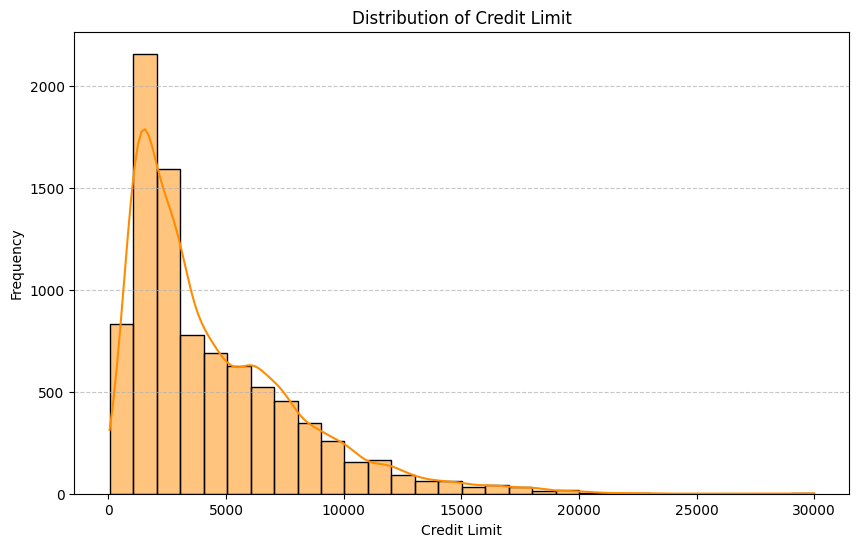

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['CREDIT_LIMIT'], kde=True, bins=30, color='darkorange')
plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
df.loc[df['CREDIT_LIMIT'].isna()]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,C15349,18.400472,0.1,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


In [28]:
from sklearn.impute import KNNImputer

# Identify the row with the null CREDIT_LIMIT
null_credit_limit_index = df[df['CREDIT_LIMIT'].isna()].index[0]

# Calculate median imputation value
median_imputation_value = df['CREDIT_LIMIT'].median()

# Prepare data for KNN Imputer
# Select numerical columns for KNN imputation, excluding 'CUST_ID' and already imputed 'MINIMUM_PAYMENTS'
# Note: We create a copy to avoid modifying the original dataframe during this calculation
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df_knn_impute = df[num_cols].copy()

# Initialize KNN imputer
# n_neighbors can be adjusted, 5 is a common default
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation
df_imputed_knn = knn_imputer.fit_transform(df_knn_impute)
df_imputed_knn = pd.DataFrame(df_imputed_knn, columns=num_cols)

# Get the KNN imputed value for the specific row
knn_imputation_value = df_imputed_knn.loc[null_credit_limit_index, 'CREDIT_LIMIT']

print(f"Median Imputation Value for CREDIT_LIMIT: {median_imputation_value}")
print(f"KNN Imputation Value for CREDIT_LIMIT: {knn_imputation_value}")

# Fill the null CREDIT_LIMIT in the original DataFrame with the KNN imputed value
df.loc[null_credit_limit_index, 'CREDIT_LIMIT'] = knn_imputation_value

# Verify that the null value has been filled
print("\nNaN counts for CREDIT_LIMIT after KNN imputation:")
display(df['CREDIT_LIMIT'].isna().sum())

Median Imputation Value for CREDIT_LIMIT: 3000.0
KNN Imputation Value for CREDIT_LIMIT: 2440.0

NaN counts for CREDIT_LIMIT after KNN imputation:


np.int64(0)

## Scaling data

In [29]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.8,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.9,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.0,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.6,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,C10005,817.714335,1.0,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [30]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.865307,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.219903,1733.143852,840.972706,0.153715,11.517318
std,2081.531879,0.255942,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.677215,2895.063757,2334.765656,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,6.000000
25%,128.281915,0.800000,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,164.653643,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,299.924288,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,819.114121,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [31]:
scale_columns= ['BALANCE','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','CASH_ADVANCE_TRX','PURCHASES_TRX']

In [32]:
from sklearn.preprocessing import RobustScaler

def apply_scaler(df, scaler_type, columns_to_scale):
    df_scaled = df.copy()
    if scaler_type == 'log':
        for col in columns_to_scale:
            # Add 1 before log to handle zero values and prevent -inf
            df_scaled[col] = np.log1p(df_scaled[col])
    elif scaler_type == 'sqrt':
        for col in columns_to_scale:
            df_scaled[col] = np.sqrt(df_scaled[col])
    elif scaler_type == 'robust':
        scaler = RobustScaler()
        df_scaled[columns_to_scale] = scaler.fit_transform(df_scaled[columns_to_scale])
    else:
        raise ValueError("Invalid scaler_type. Choose 'log', 'sqrt', or 'robust'.")
    return df_scaled


In [33]:
# Apply Log Scaling
df_log_scaled = apply_scaler(df, 'log', scale_columns)
print("DataFrame after Log Scaling (first 5 rows of scaled columns):")
# display(df_log_scaled.head())

# Apply Square Root Scaling
df_sqrt_scaled = apply_scaler(df, 'sqrt', scale_columns)
print("\nDataFrame after Square Root Scaling (first 5 rows of scaled columns):")
# display(df_sqrt_scaled.head())

# Apply Robust Scaling
df_robust_scaled = apply_scaler(df, 'robust', scale_columns)
print("\nDataFrame after Robust Scaling (first 5 rows of scaled columns):")
# display(df_robust_scaled.head())

DataFrame after Log Scaling (first 5 rows of scaled columns):

DataFrame after Square Root Scaling (first 5 rows of scaled columns):

DataFrame after Robust Scaling (first 5 rows of scaled columns):


In [34]:
from sklearn.preprocessing import StandardScaler

# Apply Standard Scaler to df_robust_scaled
standard_scaler = StandardScaler()
df_robust_standard_scaled = df_robust_scaled.copy()
df_robust_standard_scaled[scale_columns] = standard_scaler.fit_transform(df_robust_standard_scaled[scale_columns])

print("DataFrame after Robust then Standard Scaling (first 5 rows of scaled columns):")
# display(df_robust_standard_scaled.head())

# Apply Standard Scaler to df_sqrt_scaled
df_sqrt_standard_scaled = df_sqrt_scaled.copy()
df_sqrt_standard_scaled[scale_columns] = standard_scaler.fit_transform(df_sqrt_standard_scaled[scale_columns])

print("\nDataFrame after SQRT then Standard Scaling (first 5 rows of scaled columns):")
# display(df_sqrt_standard_scaled.head())

DataFrame after Robust then Standard Scaling (first 5 rows of scaled columns):

DataFrame after SQRT then Standard Scaling (first 5 rows of scaled columns):


# TSNE Visualizing

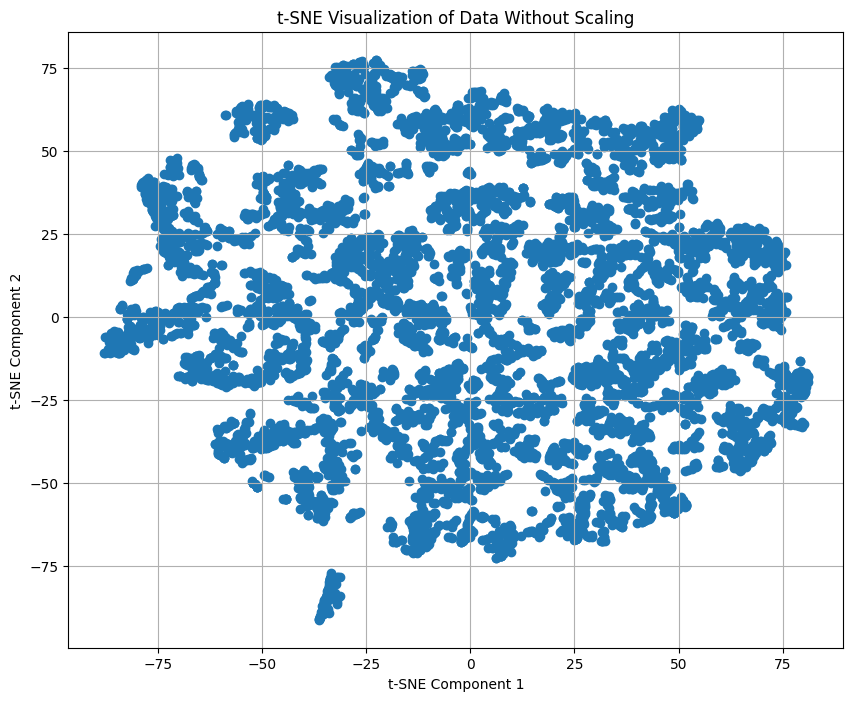

In [35]:
tsne = TSNE(perplexity=30)
tsne_results = tsne.fit_transform(df.iloc[:,1:])
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
plt.title('t-SNE Visualization of Data Without Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

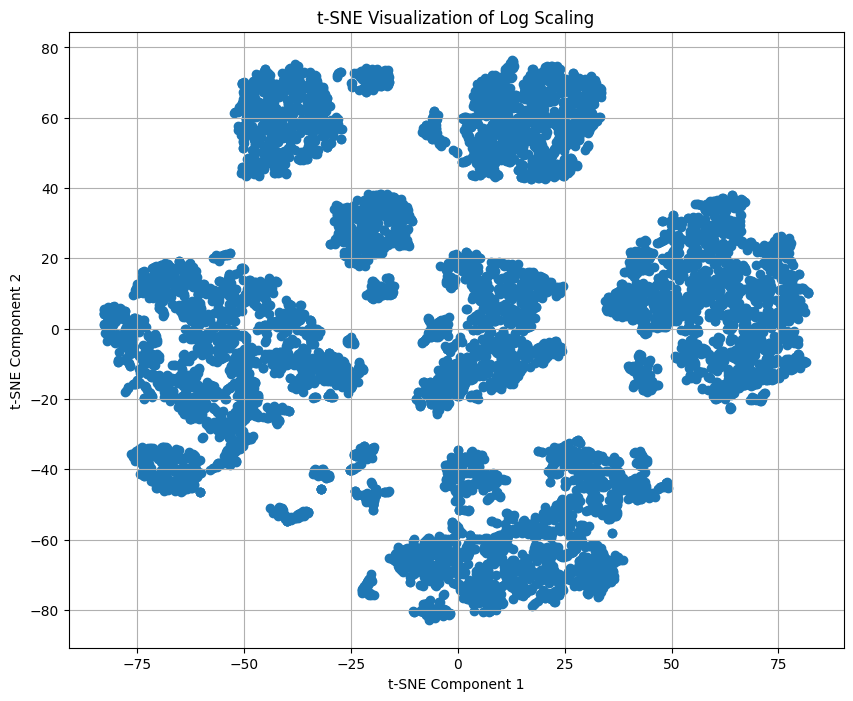

In [36]:
tsne = TSNE(perplexity=30)
tsne_results_log = tsne.fit_transform(df_log_scaled.iloc[:,1:])
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results_log[:, 0], tsne_results_log[:, 1])
plt.title('t-SNE Visualization of Log Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

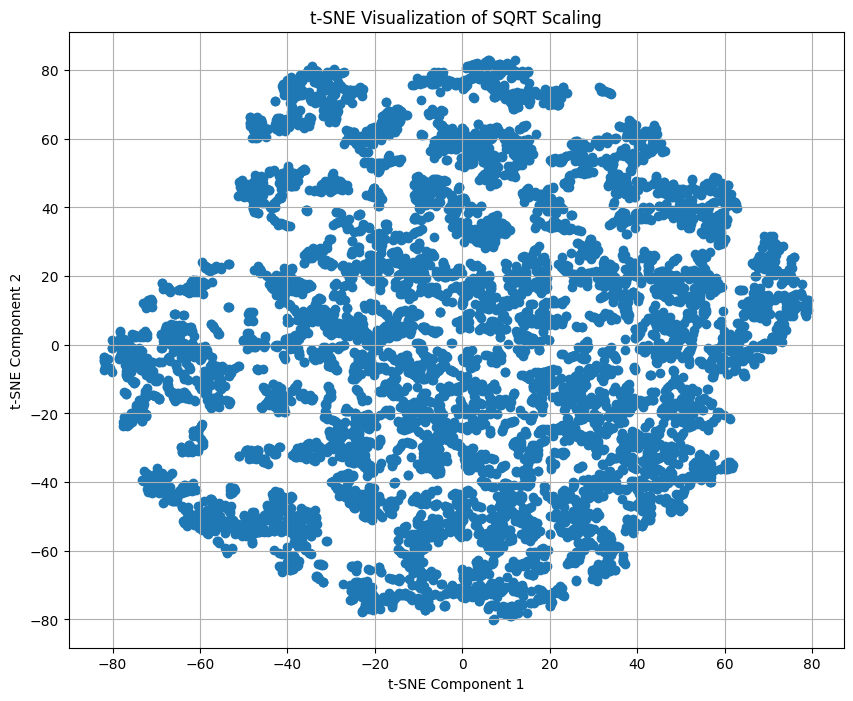

In [37]:
tsne = TSNE(perplexity=30)
tsne_results_sqrt = tsne.fit_transform(df_sqrt_scaled.iloc[:,1:])
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results_sqrt[:, 0], tsne_results_sqrt[:, 1])
plt.title('t-SNE Visualization of SQRT Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

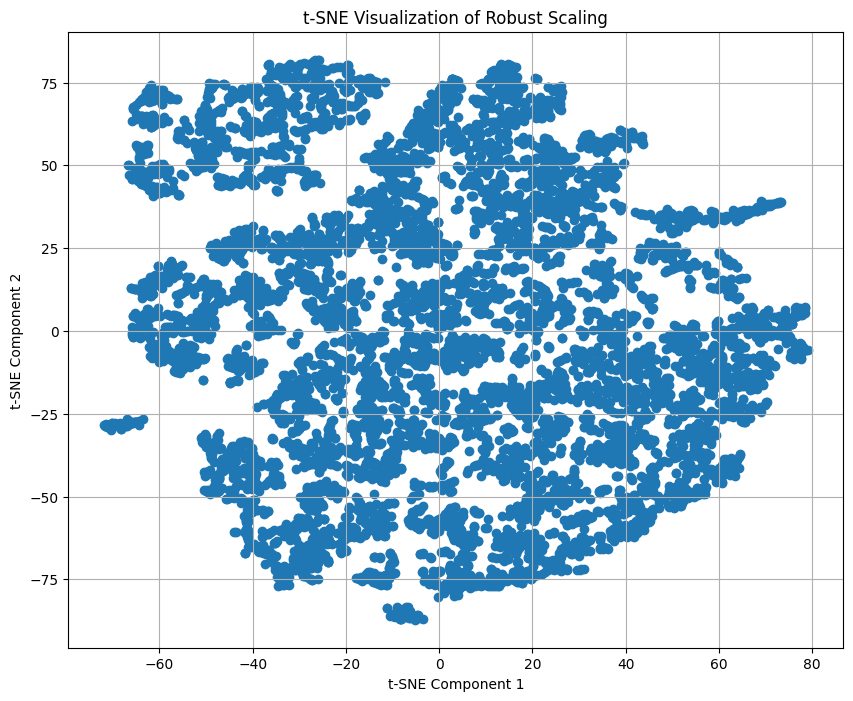

In [38]:
tsne = TSNE(perplexity=30)
tsne_results_robust = tsne.fit_transform(df_robust_scaled.iloc[:,1:])
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results_robust[:, 0], tsne_results_robust[:, 1])
plt.title('t-SNE Visualization of Robust Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

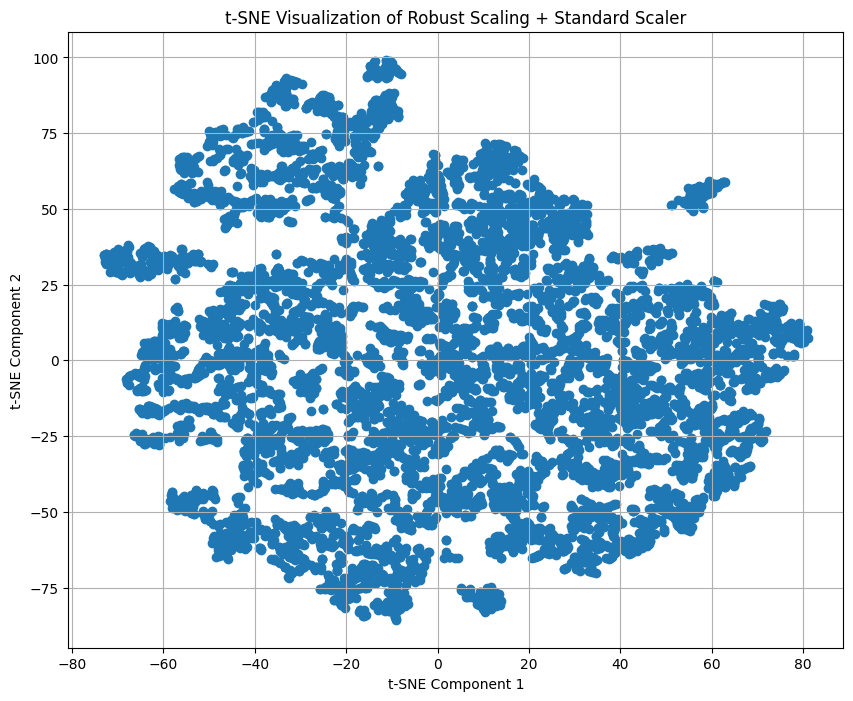

In [39]:
tsne = TSNE(perplexity=30)
tsne_results_robust_standard = tsne.fit_transform(df_robust_standard_scaled.iloc[:,1:])
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results_robust_standard[:, 0], tsne_results_robust_standard[:, 1])
plt.title('t-SNE Visualization of Robust Scaling + Standard Scaler')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

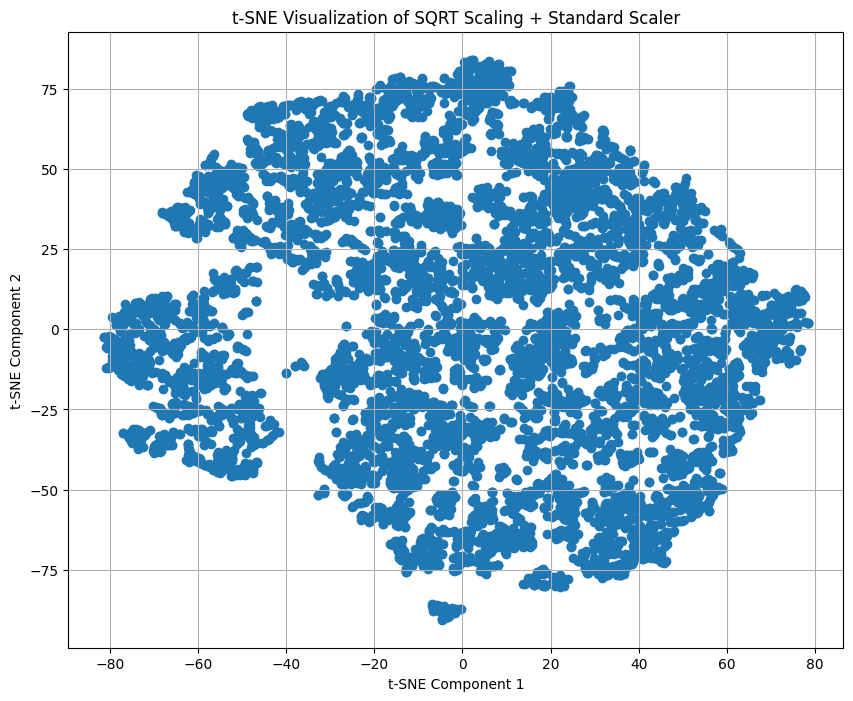

In [40]:
tsne = TSNE(perplexity=30)
tsne_results_sqrt_standard = tsne.fit_transform(df_sqrt_standard_scaled.iloc[:,1:])
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results_sqrt_standard[:, 0], tsne_results_sqrt_standard[:, 1])
plt.title('t-SNE Visualization of SQRT Scaling + Standard Scaler')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

after plotting the 3 scalers, we can see that sqrt is the worst one of them, log is best if the outliers was many

In [41]:
df[scale_columns].quantile(0.95)

BALANCE                    5909.111808
PURCHASES                  3998.619500
ONEOFF_PURCHASES           2671.094000
INSTALLMENTS_PURCHASES     1750.087500
CASH_ADVANCE               4647.169122
CREDIT_LIMIT              12000.000000
PAYMENTS                   6082.090595
MINIMUM_PAYMENTS           2719.566935
CASH_ADVANCE_TRX             15.000000
PURCHASES_TRX                57.000000
Name: 0.95, dtype: float64

In [42]:
df[scale_columns].quantile(0.95)

BALANCE                    5909.111808
PURCHASES                  3998.619500
ONEOFF_PURCHASES           2671.094000
INSTALLMENTS_PURCHASES     1750.087500
CASH_ADVANCE               4647.169122
CREDIT_LIMIT              12000.000000
PAYMENTS                   6082.090595
MINIMUM_PAYMENTS           2719.566935
CASH_ADVANCE_TRX             15.000000
PURCHASES_TRX                57.000000
Name: 0.95, dtype: float64

In [43]:
outlier_counts = {}
for col in scale_columns:
    quantile_95 = df[col].quantile(0.95)
    count_greater_than_95_quantile = (df[col] > quantile_95).sum()
    outlier_counts[col] = count_greater_than_95_quantile

print("Number of values greater than the 95th percentile for each scaled column:")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

Number of values greater than the 95th percentile for each scaled column:
BALANCE: 448
PURCHASES: 448
ONEOFF_PURCHASES: 448
INSTALLMENTS_PURCHASES: 448
CASH_ADVANCE: 448
CREDIT_LIMIT: 367
PAYMENTS: 448
MINIMUM_PAYMENTS: 448
CASH_ADVANCE_TRX: 418
PURCHASES_TRX: 441


In [44]:
df[scale_columns].max()

BALANCE                   19043.13856
PURCHASES                 49039.57000
ONEOFF_PURCHASES          40761.25000
INSTALLMENTS_PURCHASES    22500.00000
CASH_ADVANCE              47137.21176
CREDIT_LIMIT              30000.00000
PAYMENTS                  50721.48336
MINIMUM_PAYMENTS          76406.20752
CASH_ADVANCE_TRX            123.00000
PURCHASES_TRX               358.00000
dtype: float64

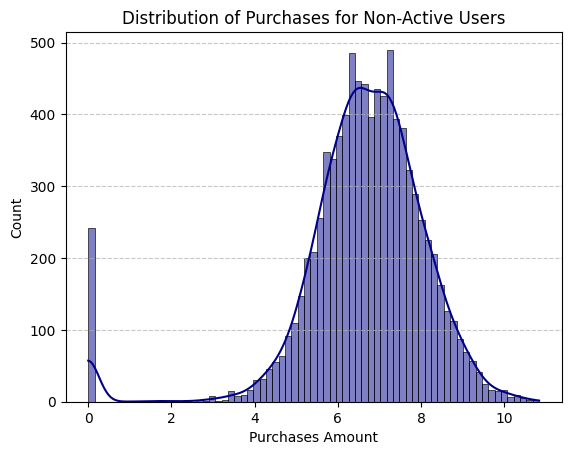

In [45]:
sns.histplot(x=df_log_scaled['PAYMENTS'], kde=True, color='darkblue')
plt.title('Distribution of Purchases for Non-Active Users')
plt.xlabel('Purchases Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

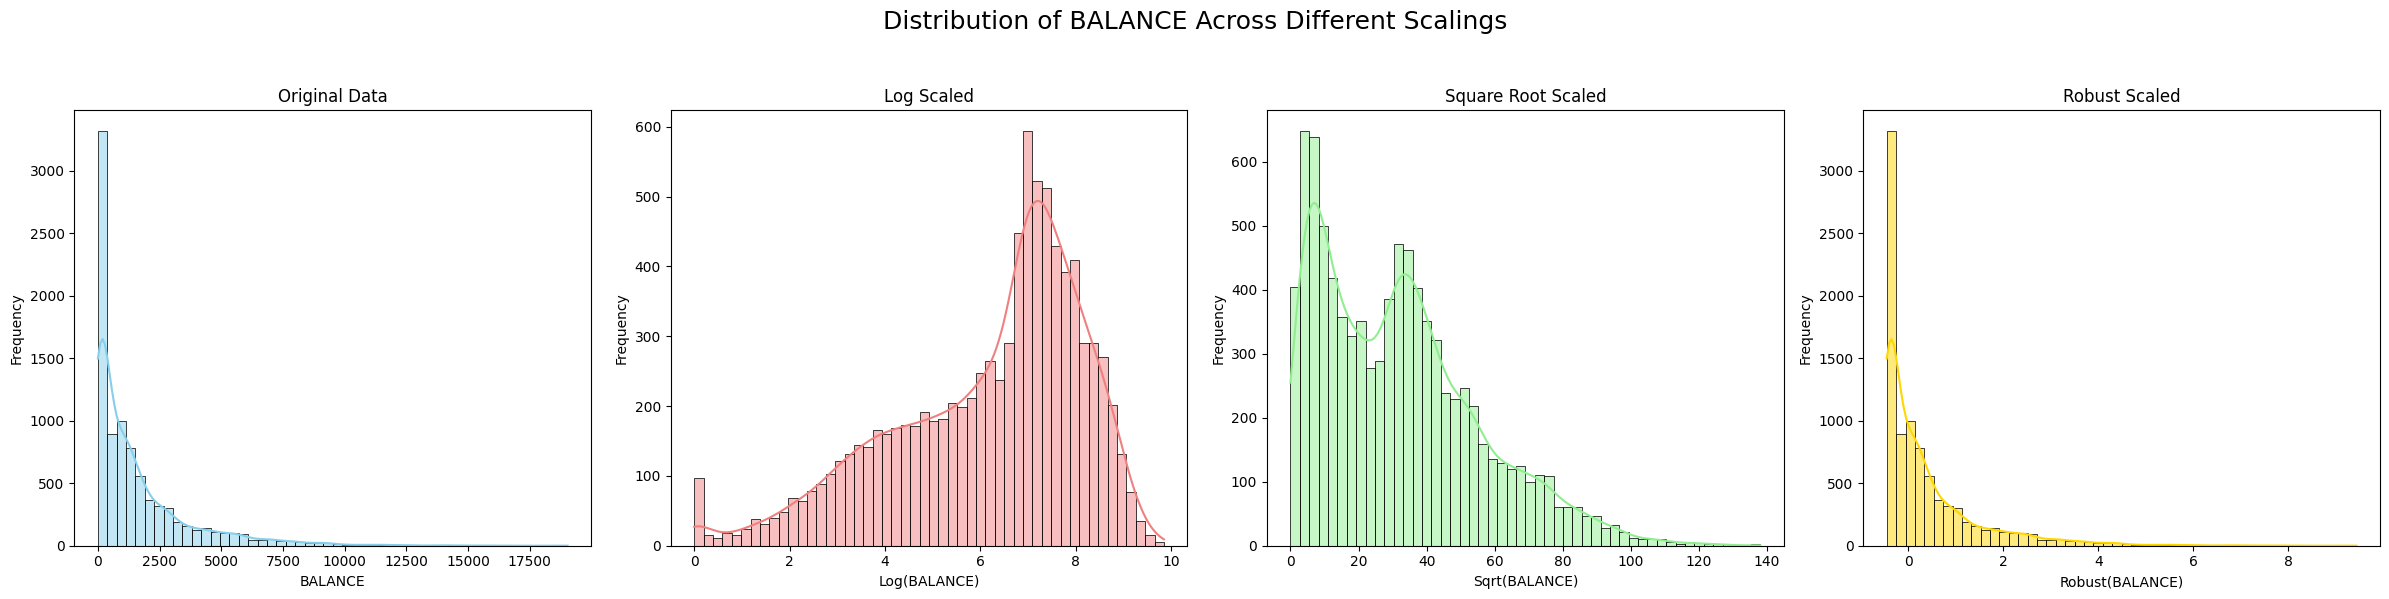

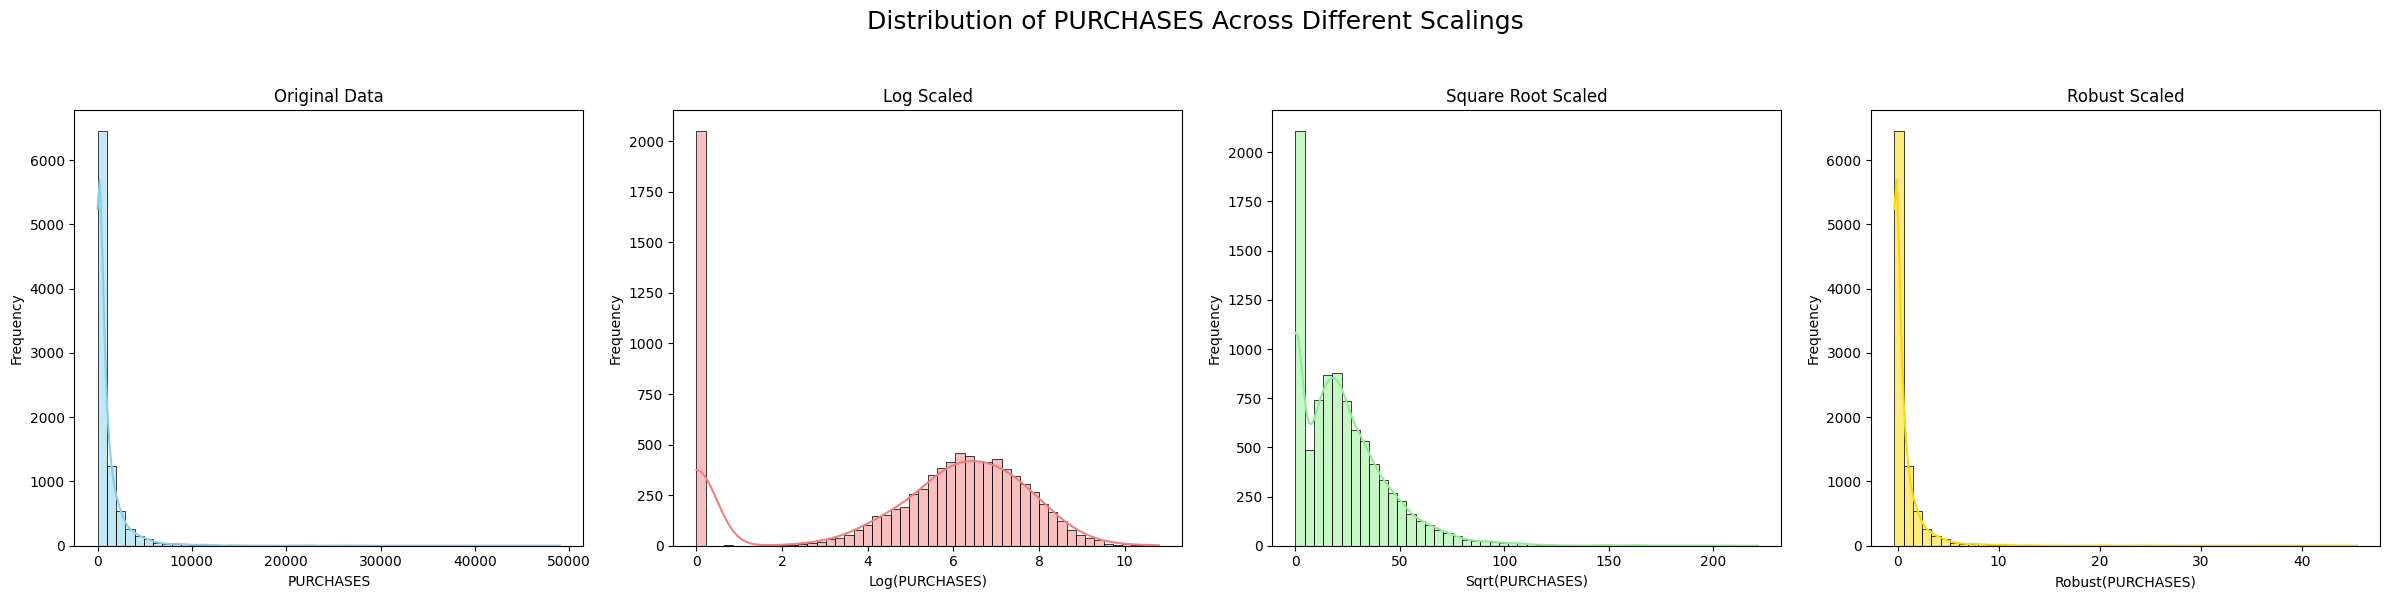

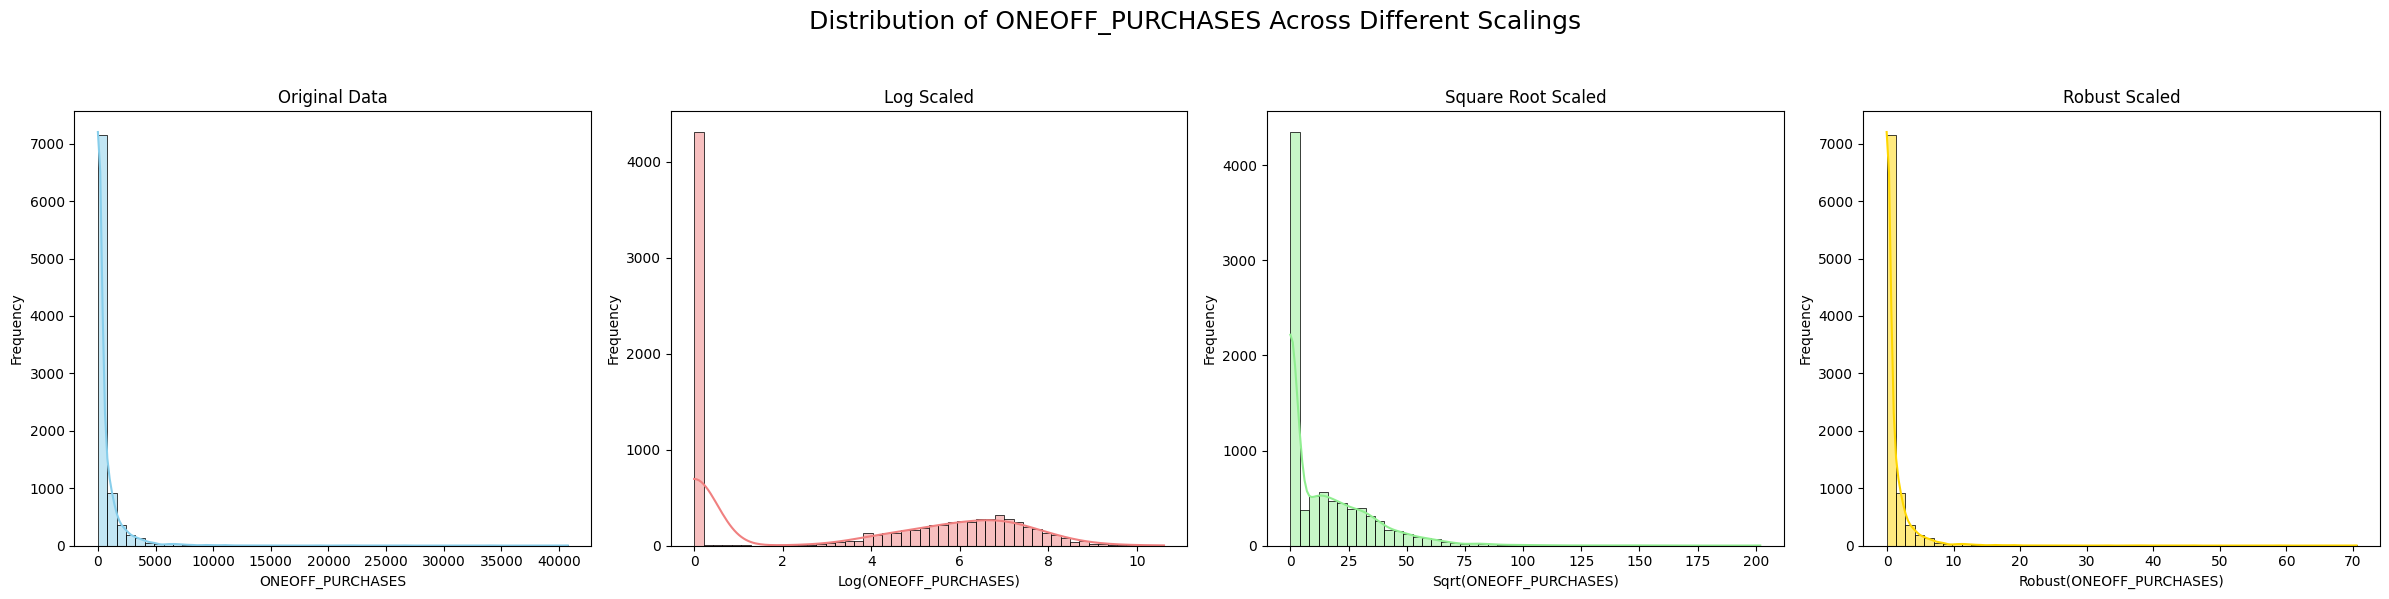

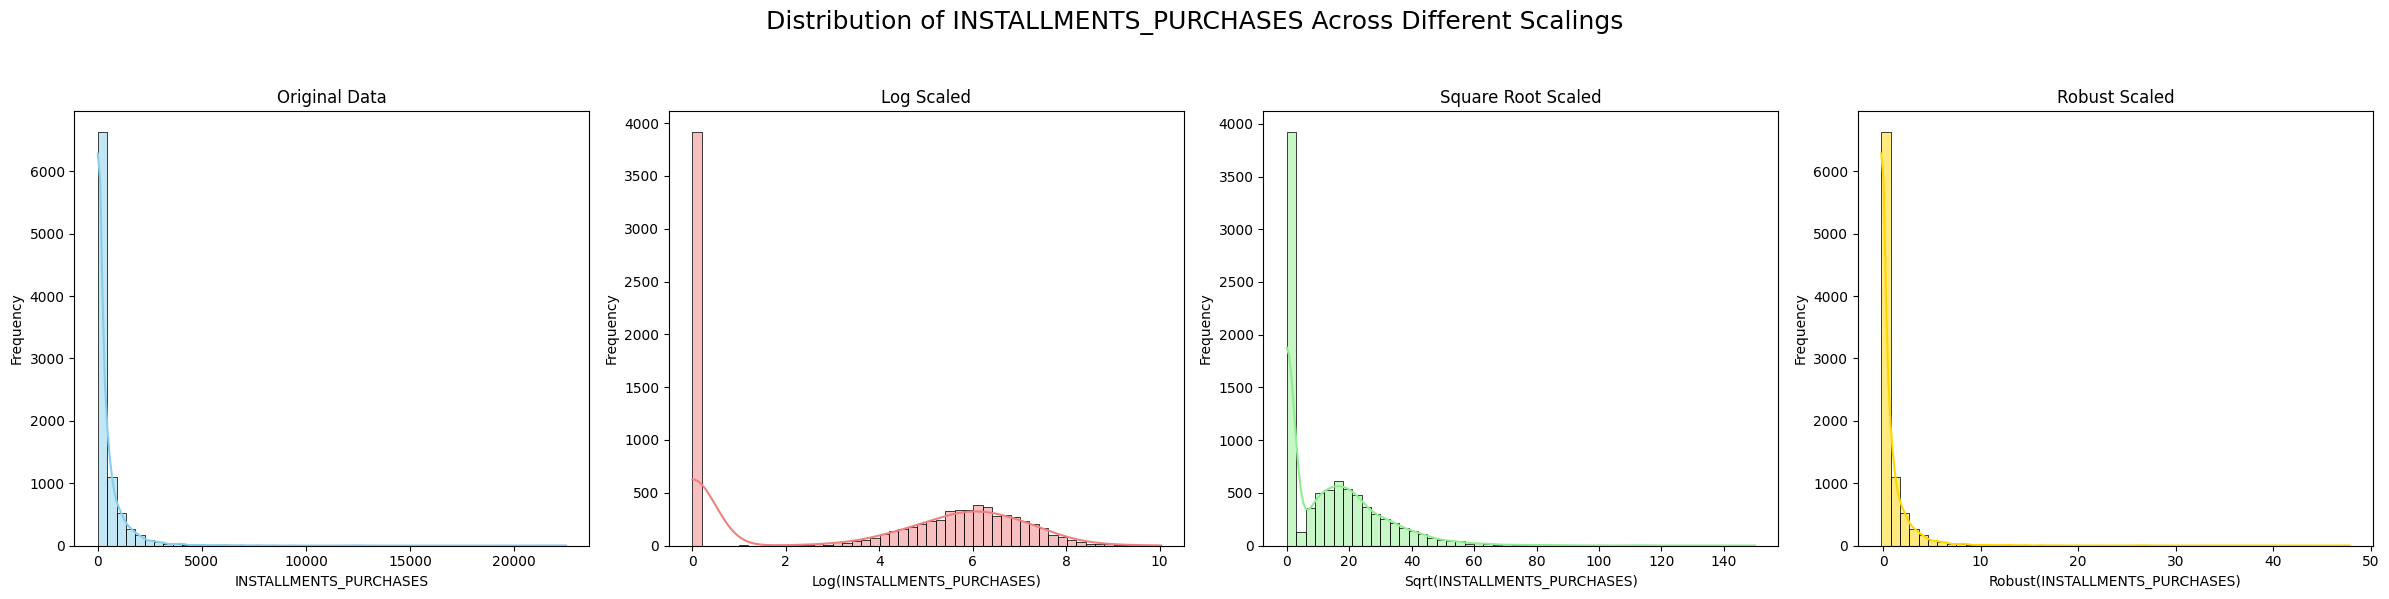

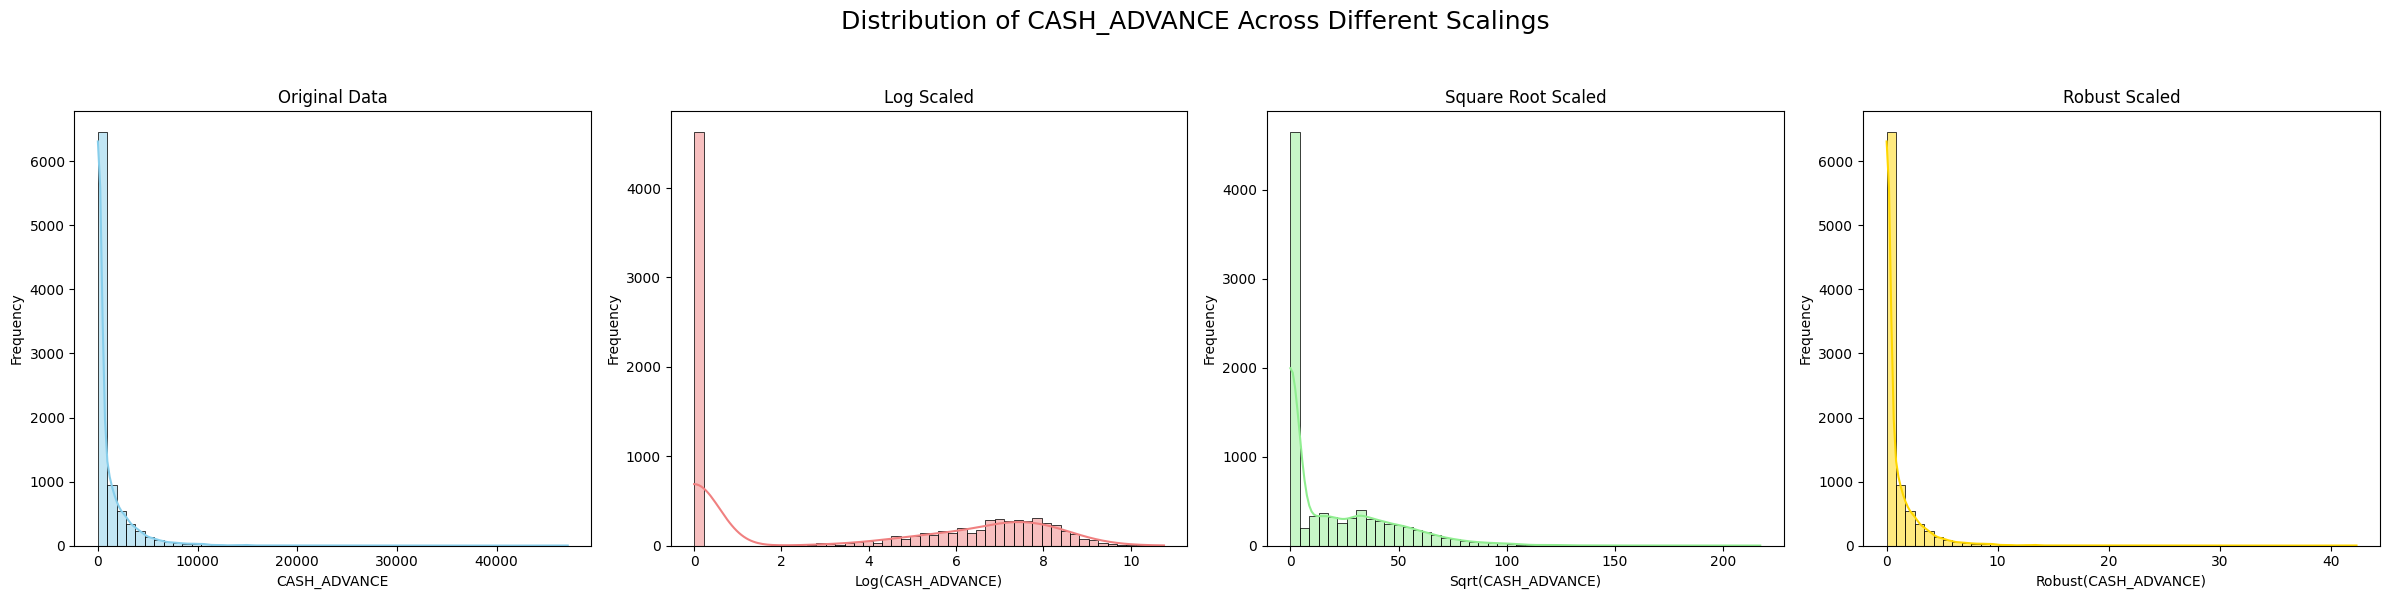

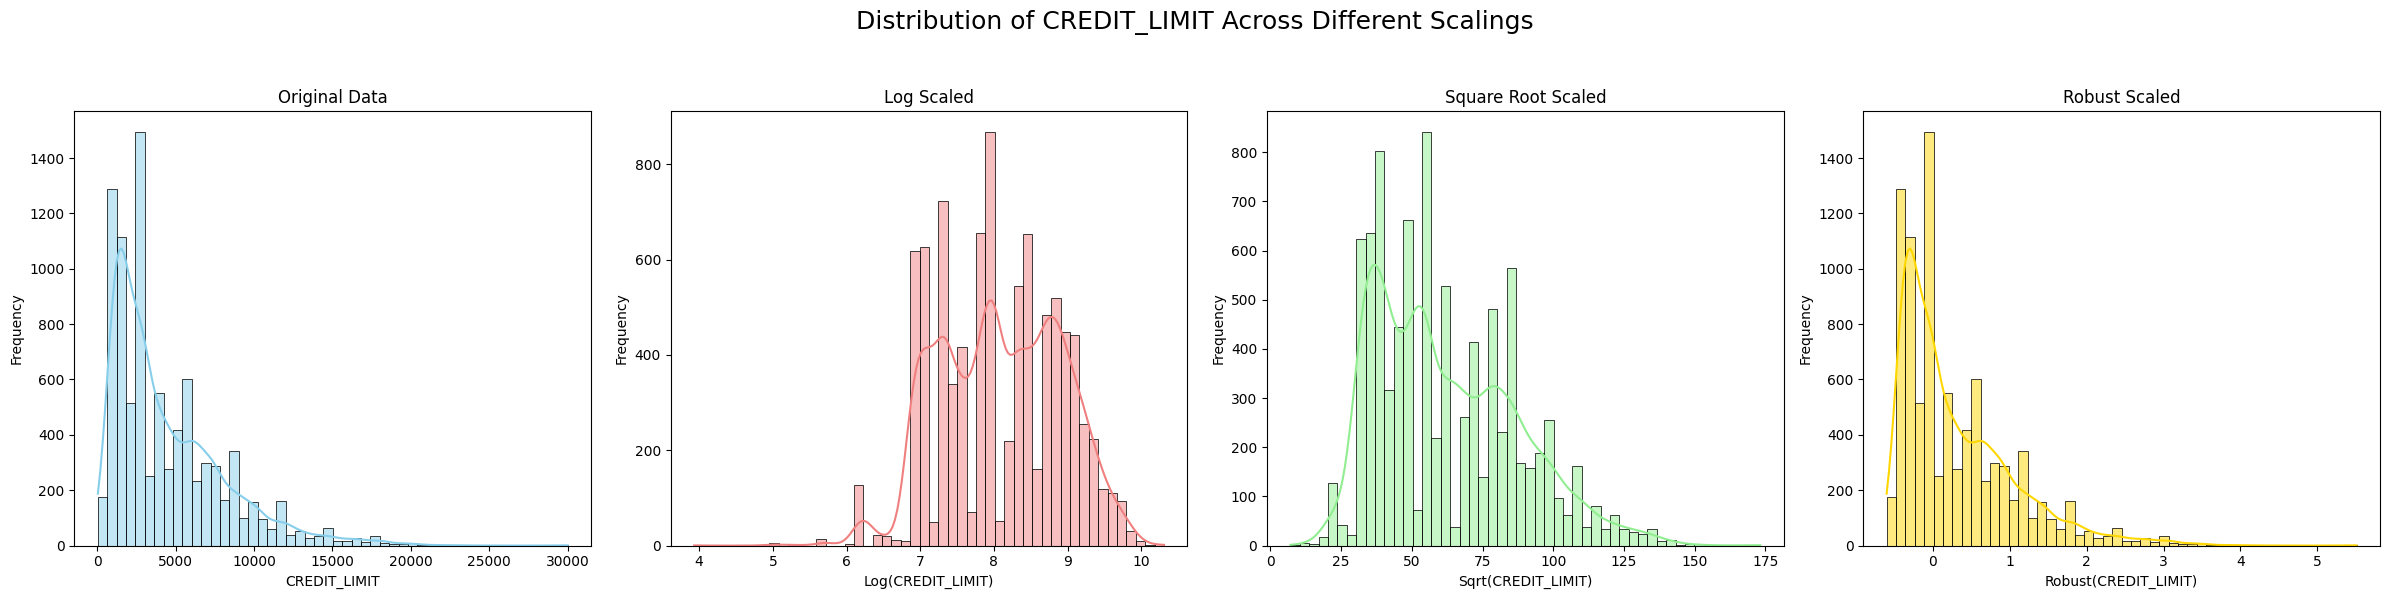

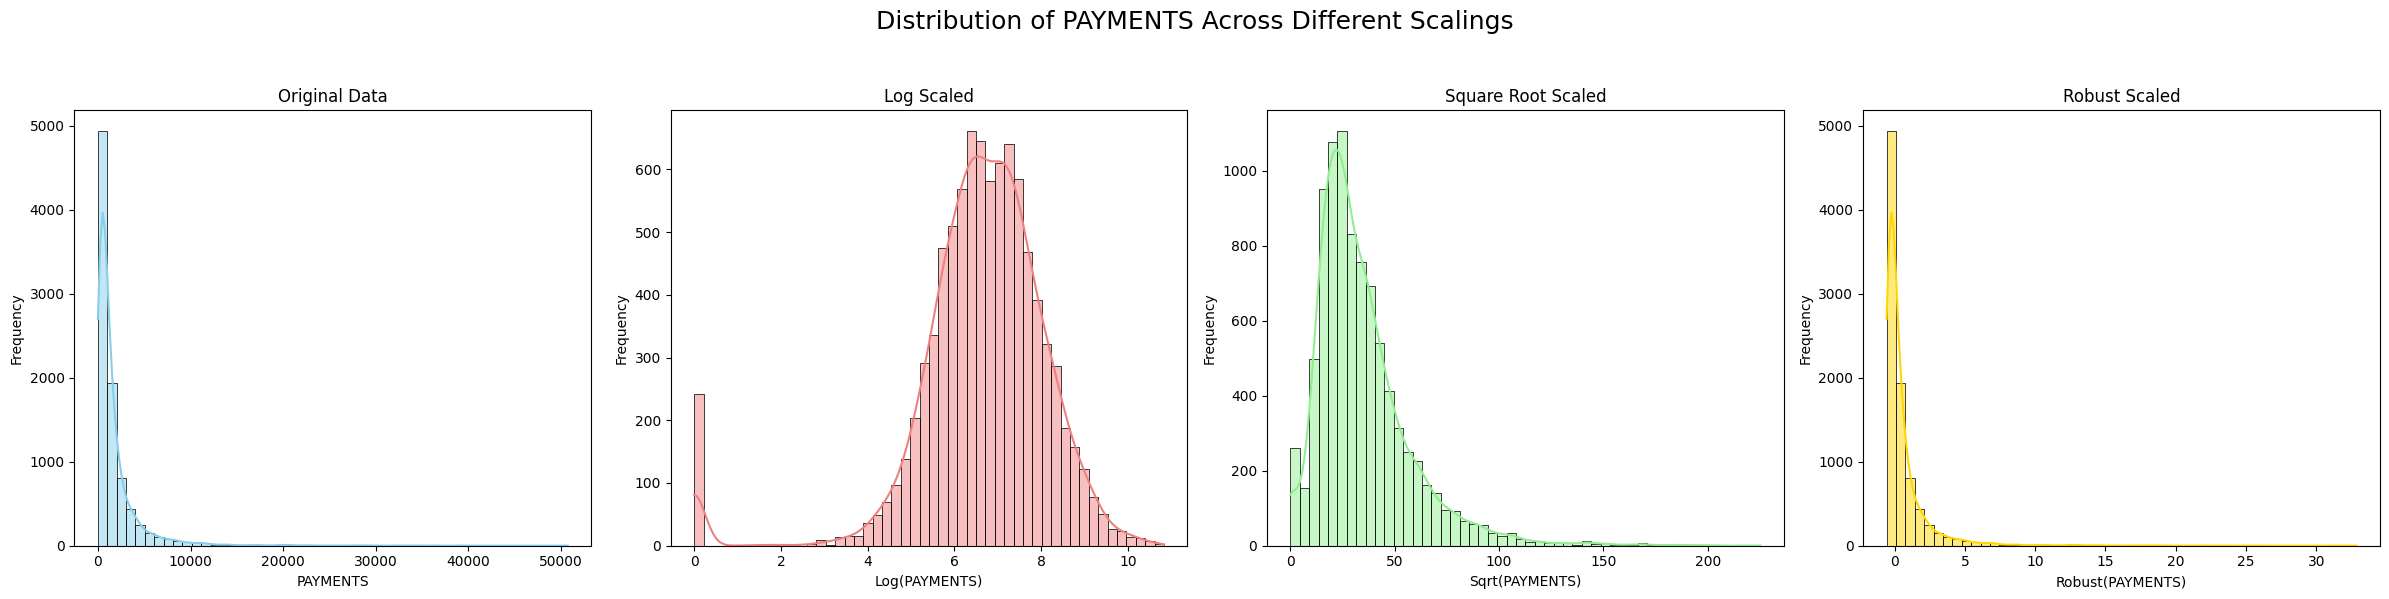

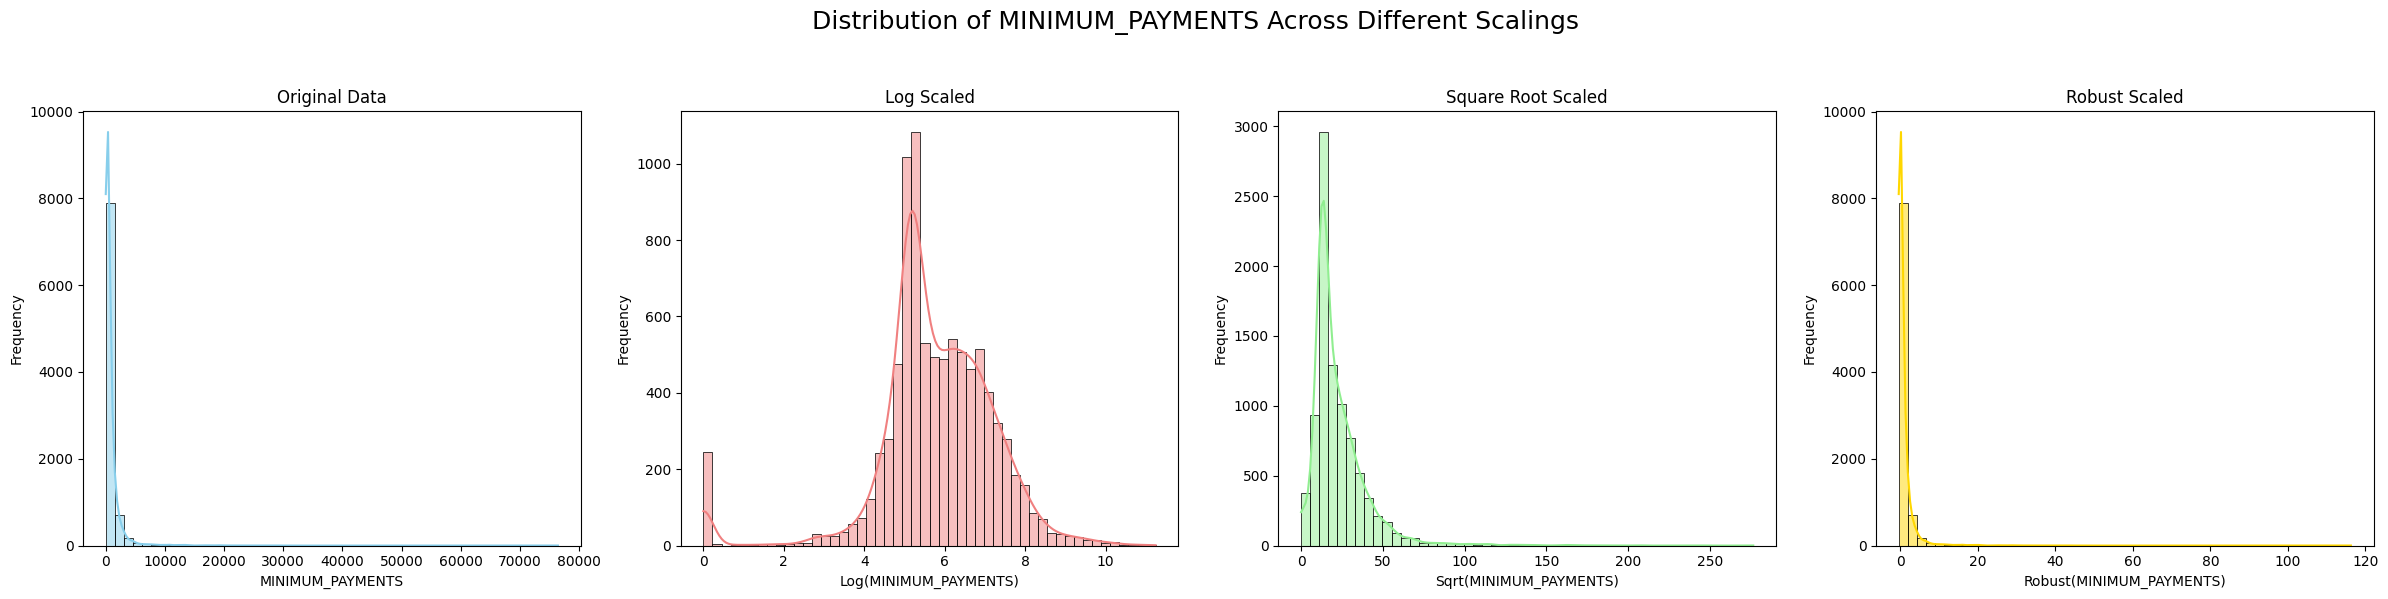

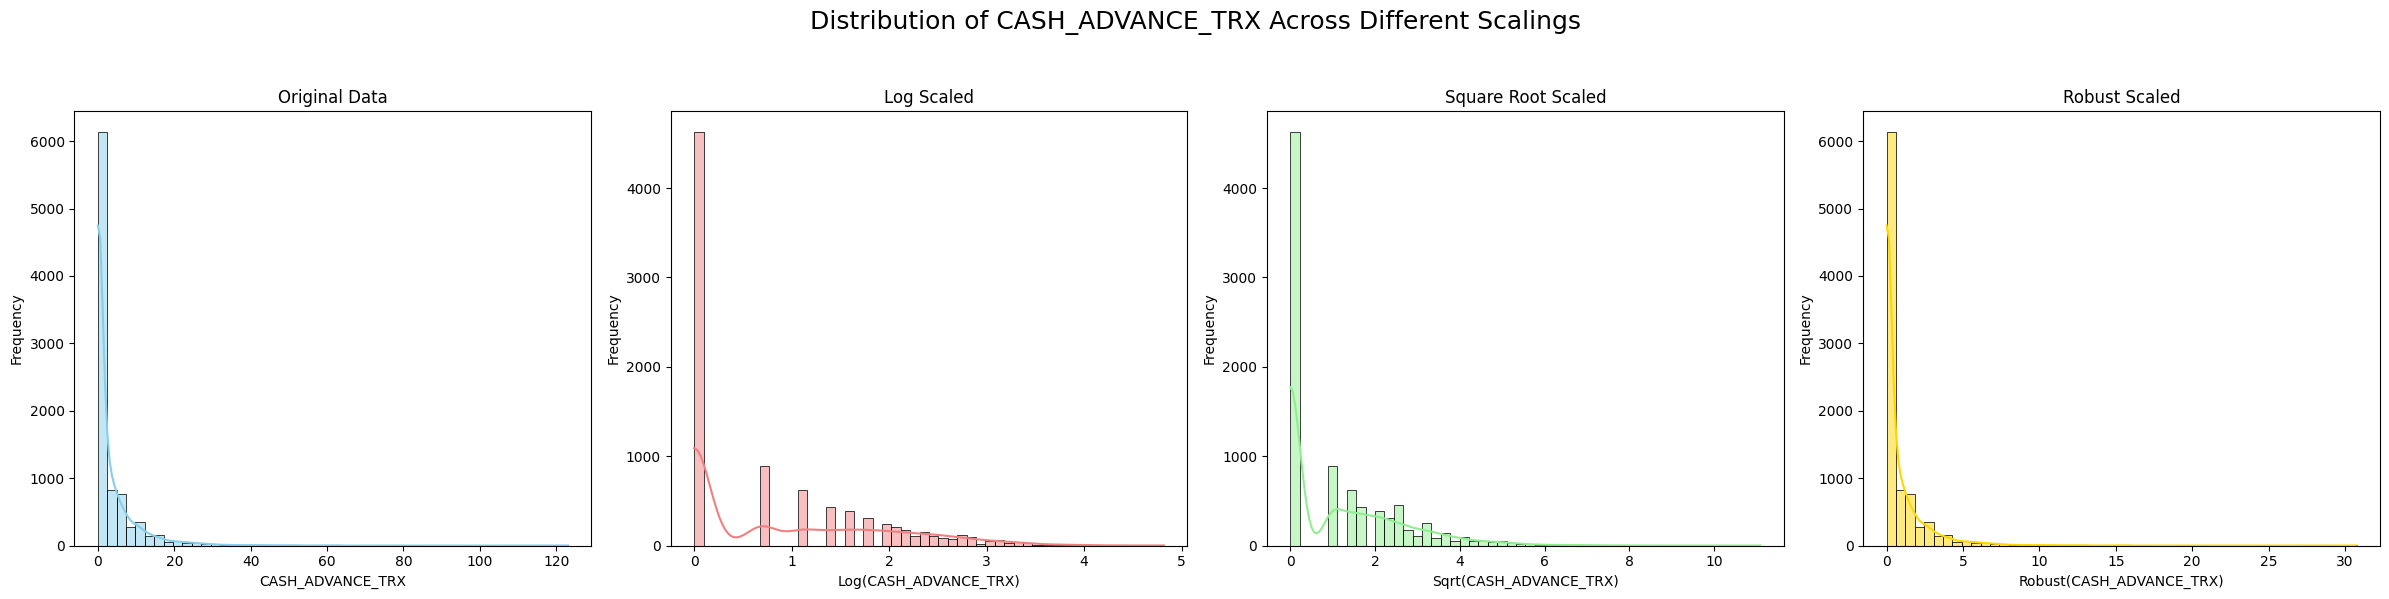

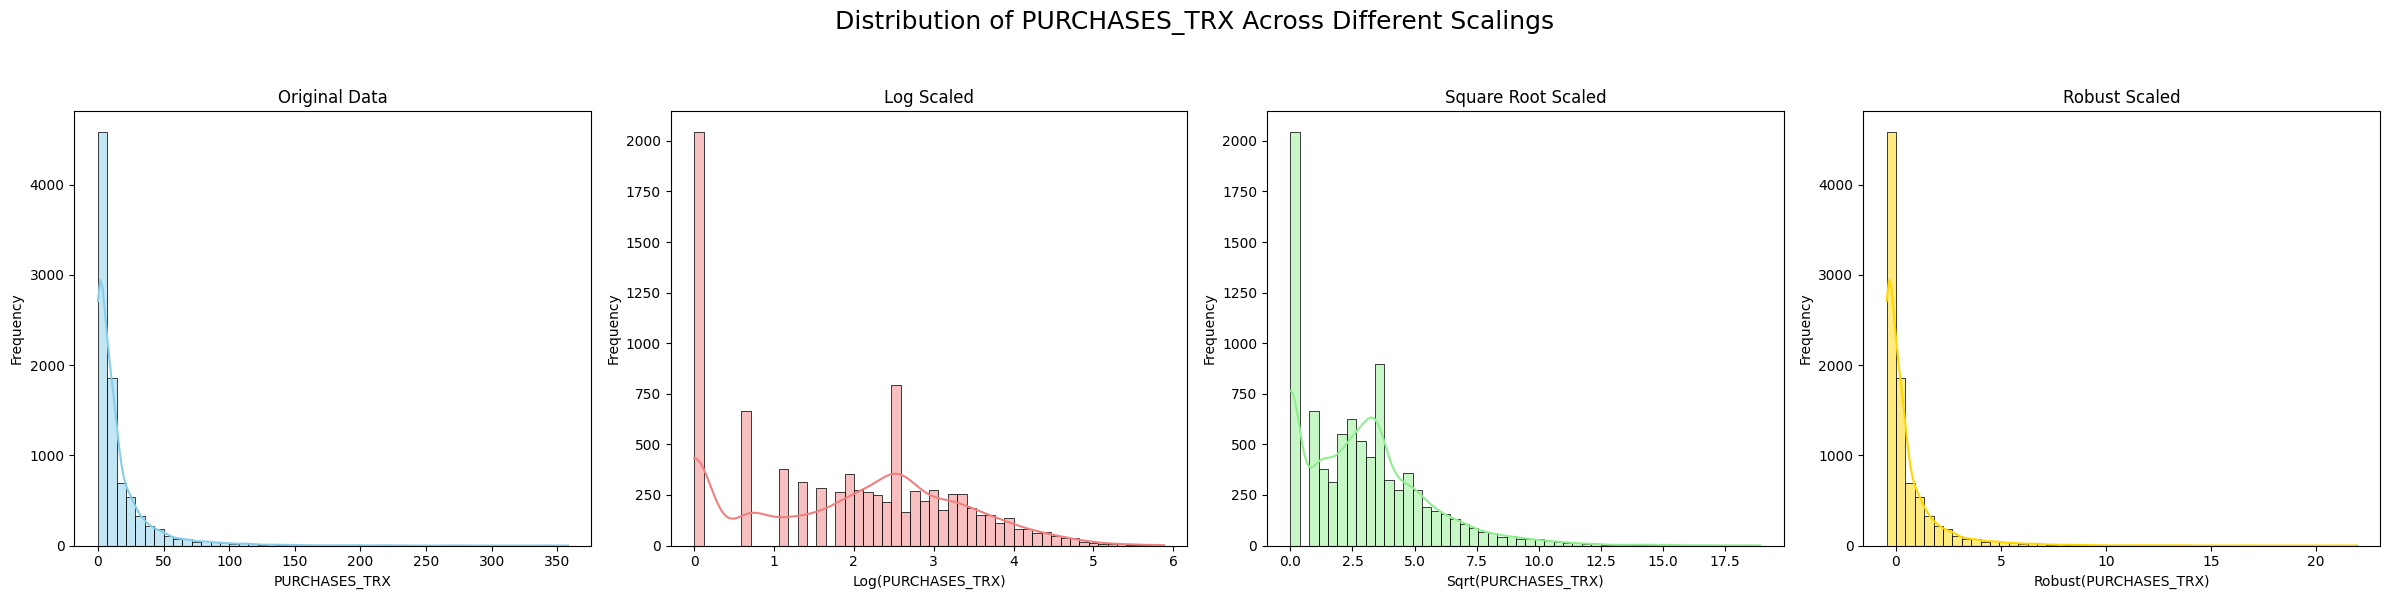

In [46]:
def plot_scaled_distributions(column_name, original_df, log_df, sqrt_df, robust_df):
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(f'Distribution of {column_name} Across Different Scalings', fontsize=18, y=1.02)

    # Original Distribution
    sns.histplot(original_df[column_name], kde=True, ax=axes[0], color='skyblue', bins=50)
    axes[0].set_title('Original Data')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frequency')

    # Log Scaled Distribution
    sns.histplot(log_df[column_name], kde=True, ax=axes[1], color='lightcoral', bins=50)
    axes[1].set_title('Log Scaled')
    axes[1].set_xlabel(f'Log({column_name})')
    axes[1].set_ylabel('Frequency')

    # Square Root Scaled Distribution
    sns.histplot(sqrt_df[column_name], kde=True, ax=axes[2], color='lightgreen', bins=50)
    axes[2].set_title('Square Root Scaled')
    axes[2].set_xlabel(f'Sqrt({column_name})')
    axes[2].set_ylabel('Frequency')

    # Robust Scaled Distribution
    sns.histplot(robust_df[column_name], kde=True, ax=axes[3], color='gold', bins=50)
    axes[3].set_title('Robust Scaled')
    axes[3].set_xlabel(f'Robust({column_name})')
    axes[3].set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()

# Loop through scale_columns and call the function to plot distributions
for col in scale_columns:
    plot_scaled_distributions(col, df, df_log_scaled, df_sqrt_scaled, df_robust_scaled)


In [47]:
df['PURCHASES'].value_counts()

PURCHASES
0.00       2044
45.65        27
150.00       16
60.00        16
100.00       13
           ... 
356.32        1
558.08        1
50.85         1
1053.52       1
1401.54       1
Name: count, Length: 6203, dtype: int64

from the distributions all the features have a large number of Zeros in it

for log no need to make any scaler after it<br>
for sqrt and robust we may need to apply some scaler

# UMAP Visualizing

2026-02-19 21:05:48.698954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771535148.915415      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771535148.981043      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771535149.508421      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771535149.508484      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771535149.508488      17 computation_placer.cc:177] computation placer alr

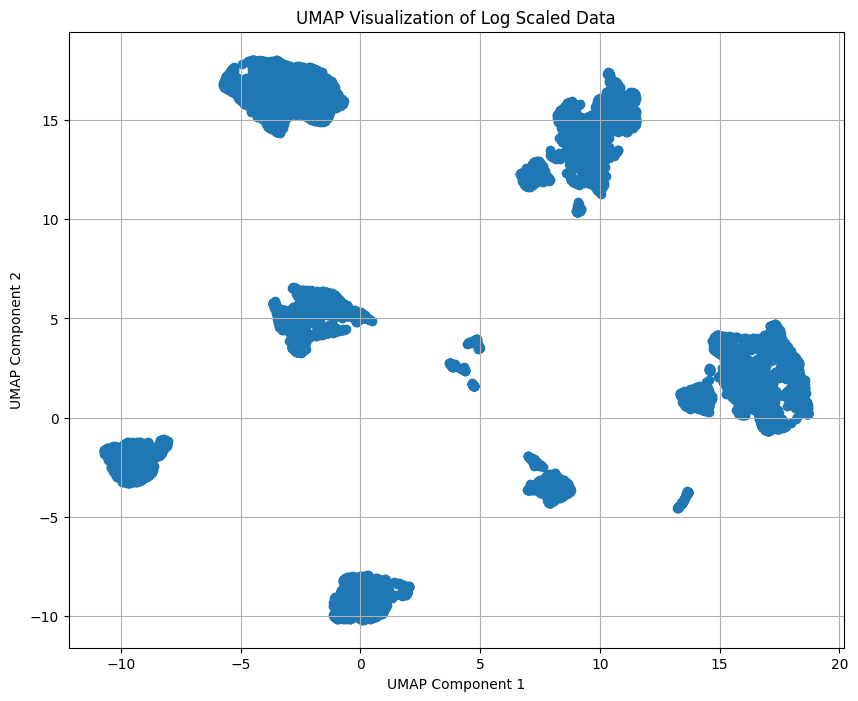

In [48]:
import umap
# import umap.plot # This line is causing the ImportError, as umap.plot has additional dependencies

reducer = umap.UMAP(random_state=42)
umap_results_log = reducer.fit_transform(df_log_scaled.iloc[:,1:])

plt.figure(figsize=(10, 8))
plt.scatter(umap_results_log[:, 0], umap_results_log[:, 1])
plt.title('UMAP Visualization of Log Scaled Data')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


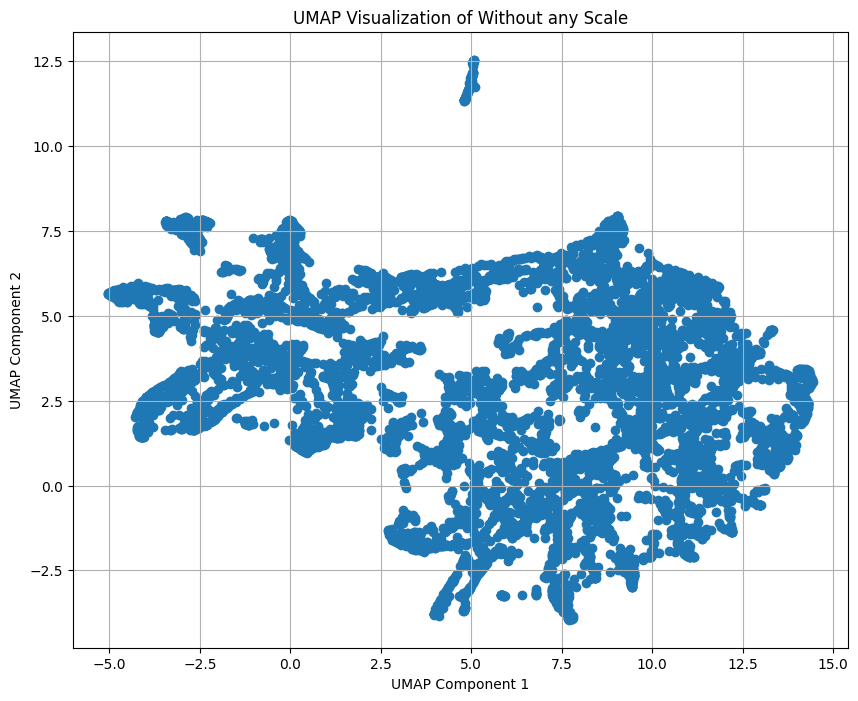

In [49]:
reducer = umap.UMAP(random_state=42)
umap_results_log = reducer.fit_transform(df.iloc[:,1:])

plt.figure(figsize=(10, 8))
plt.scatter(umap_results_log[:, 0], umap_results_log[:, 1])
plt.title('UMAP Visualization of Without any Scale')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


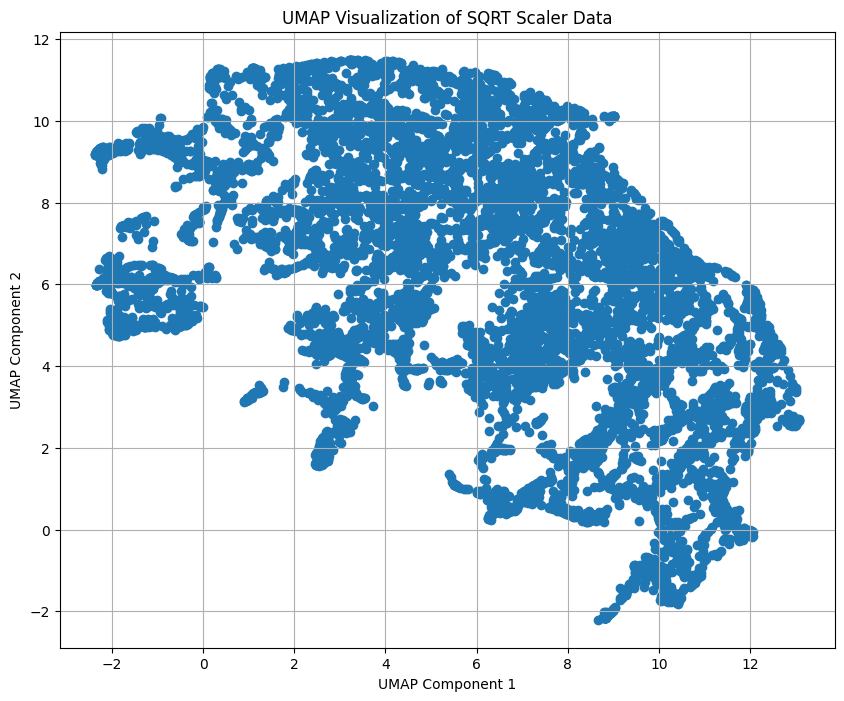

In [50]:
reducer = umap.UMAP(random_state=42)
umap_results_log = reducer.fit_transform(df_sqrt_scaled.iloc[:,1:])

plt.figure(figsize=(10, 8))
plt.scatter(umap_results_log[:, 0], umap_results_log[:, 1])
plt.title('UMAP Visualization of SQRT Scaler Data')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


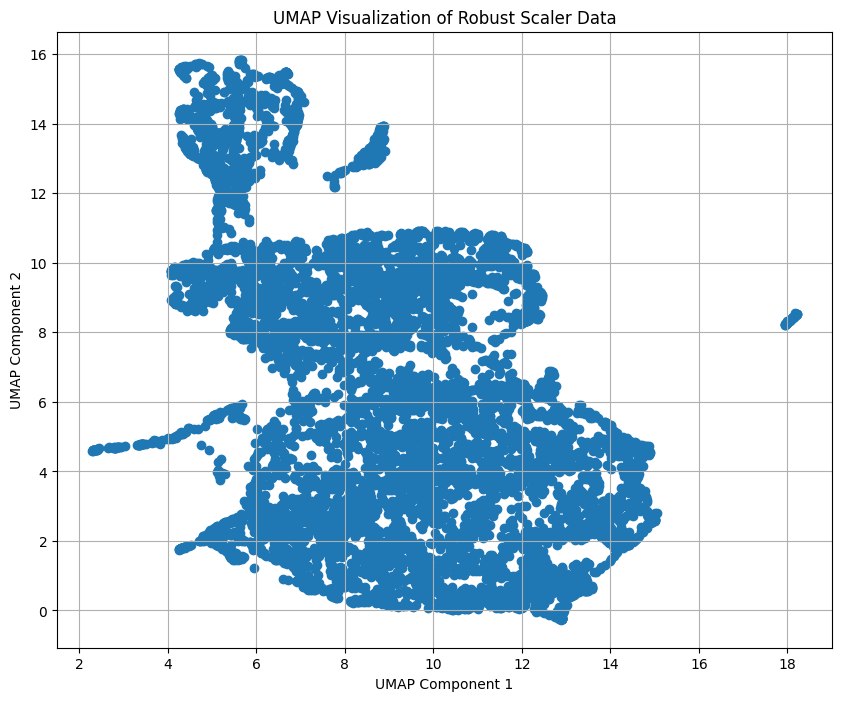

In [51]:
reducer = umap.UMAP(random_state=42)
umap_results_log = reducer.fit_transform(df_robust_scaled.iloc[:,1:])

plt.figure(figsize=(10, 8))
plt.scatter(umap_results_log[:, 0], umap_results_log[:, 1])
plt.title('UMAP Visualization of Robust Scaler Data')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

## Now we can say that we have 7 clusters frmo U-MAP and from TSNE

## PCA

In [52]:
from sklearn.decomposition import PCA

In [53]:
pca_logged =PCA(n_components= .95)
pca_feature= pca_logged.fit_transform(df_log_scaled.iloc[:,1:])

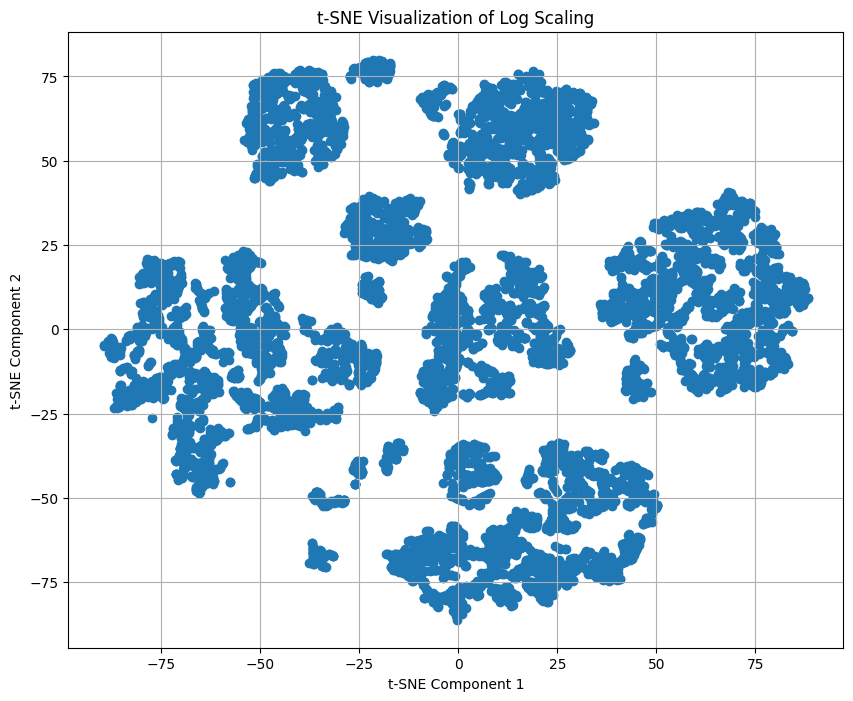

In [54]:
tsne = TSNE(perplexity=30)
tsne_results_log = tsne.fit_transform(pca_feature)
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results_log[:, 0], tsne_results_log[:, 1])
plt.title('t-SNE Visualization of Log Scaling')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

we will see that there is no effect of using PCA then Visualizing with TSNE

# Models

## K-Means

In [55]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters=7, random_state=0, n_init=10,max_iter=500)
kmeans_model =k_means.fit(df_log_scaled.iloc[:,1:])

## GMM

In [56]:
from sklearn.mixture import GaussianMixture
GMM = GaussianMixture(n_components=7, random_state=0, n_init=15,max_iter=500)
GMM_model =GMM.fit(df_log_scaled.iloc[:,1:])

## Results

In [57]:
from sklearn.metrics import silhouette_score

def calculate_silhouette_score(model, data):
    """
    Calculates the silhouette score for a given clustering model and data.

    Args:
        model: The fitted clustering model (e.g., KMeans, GaussianMixture).
        data: The dataset used for clustering.

    Returns:
        float: The silhouette score.
    """
    if hasattr(model, 'labels_'):
        labels = model.labels_
    elif hasattr(model, 'predict'):
        labels = model.predict(data)
    else:
        raise ValueError("Model must have 'labels_' attribute or 'predict' method.")

    # Silhouette score requires at least 2 clusters and more than n_samples - 1 unique labels
    if len(set(labels)) < 2 or len(data) < 2:
        return -1 # or handle as an error/special case

    return silhouette_score(data, labels)

In [58]:
kmeans_silhouette = calculate_silhouette_score(kmeans_model, df_log_scaled.iloc[:,1:])
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")

# Calculate and print silhouette score for GMM
gmm_silhouette = calculate_silhouette_score(GMM_model, df_log_scaled.iloc[:,1:])
print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")

K-Means Silhouette Score: 0.4214
GMM Silhouette Score: 0.4122


we will chose GMM although KMeans look better from Silhouette score but most of our data had been normalized, for inference

In [59]:
# Predict GMM clusters using the data the model was fitted on
gmm_predictions = GMM_model.predict(df_log_scaled.iloc[:,1:])

# Predict KMeans clusters using the data the model was fitted on
kmeans_predictions = kmeans_model.predict(df_log_scaled.iloc[:,1:])

# Add these predictions as new columns to the original DataFrame (df_log_scaled)
df_log_scaled['GMM_cls'] = gmm_predictions
df_log_scaled['KMeans_cls'] = kmeans_predictions

df_log_scaled.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,GMM_cls,KMeans_cls
0,C10001,3.735304,0.8,4.568506,0.000000,4.568506,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,12,1,3
1,C10002,8.071989,0.9,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.250000,1.609438,0.000000,8.853808,8.319725,6.978531,0.222222,12,3,2
2,C10003,7.822504,1.0,6.651791,6.651791,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,12,6,1
3,C10004,7.419183,0.6,7.313220,7.313220,0.000000,5.331694,0.083333,0.083333,0.000000,0.083333,0.693147,0.693147,8.922792,0.000000,0.000000,0.000000,12,2,4
4,C10005,6.707735,1.0,2.833213,2.833213,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,12,6,1


In [60]:
df_log_scaled.drop('CUST_ID', axis=1).groupby('GMM_cls').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMeans_cls
GMM_cls,,,,,,,,,,,,,,,,,,
0,7.303422,0.950437,5.740324,0.000000,5.740324,6.939954,0.653516,0.000000,0.605983,0.262574,1.630190,2.238487,8.065144,6.944829,6.556101,0.047232,11.316594,4.934498
1,4.253876,0.770039,5.725518,0.000000,5.725518,0.000000,0.705972,0.000000,0.672467,0.000000,0.000000,2.286326,7.767456,5.893891,5.127436,0.305880,11.511459,2.997764
2,7.191984,0.915174,5.618768,5.618768,0.000000,6.850014,0.275094,0.275094,0.000000,0.292492,1.727244,1.535119,8.143325,6.774746,6.148181,0.058157,11.351990,3.881841
3,6.988595,0.870476,0.000000,0.000000,0.000000,6.857190,0.000000,0.000000,0.000000,0.272965,1.650242,0.000000,7.989089,6.534172,6.014685,0.044269,11.317312,2.000000
4,7.463901,0.964349,7.077933,6.284970,6.022750,6.893340,0.775613,0.394571,0.626893,0.291421,1.779703,3.102296,8.382113,7.415484,6.530054,0.068862,11.618022,5.844270
5,6.150910,0.924633,7.266343,6.423431,6.204951,0.000000,0.810012,0.456733,0.644674,0.000000,0.000000,3.193787,8.381422,7.133754,5.671414,0.256526,11.798870,0.166102
6,5.286855,0.748082,5.962897,5.962897,0.000000,0.000000,0.355049,0.355049,0.000000,0.000000,0.000000,1.672303,8.071488,6.170912,5.196195,0.136120,11.556595,1.005613


In [61]:
# Drop non-numeric and cluster columns for global statistics calculation
features_df = df_log_scaled.drop(columns=['CUST_ID', 'GMM_cls', 'KMeans_cls'])

# Calculate global mean and standard deviation for each feature
global_mean = features_df.mean()
global_std = features_df.std()

# Group by KMeans_cls and calculate the mean for each cluster
cluster_means = df_log_scaled.drop(columns=['CUST_ID', 'KMeans_cls']).groupby('GMM_cls').mean()

# Calculate the Z-score profile for each cluster
z_score_profile = (cluster_means - global_mean) / global_std

print("Z-score profile for each KMeans cluster:")
display(z_score_profile)

Z-score profile for each KMeans cluster:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
GMM_cls,,,,,,,,,,,,,,,,,
0,0.567120,0.332612,0.288212,-0.987034,0.774551,1.015301,0.406520,-0.678623,0.607742,0.636765,0.805119,0.250212,-0.036185,0.201217,0.519259,-0.364043,-0.149981
1,-0.947578,-0.372225,0.283136,-0.987034,0.769749,-0.930681,0.537212,-0.678623,0.775018,-0.675311,-0.810023,0.285034,-0.399380,-0.459019,-0.424657,0.520223,-0.004378
2,0.511769,0.194836,0.246539,0.743753,-1.087393,0.990082,-0.536304,0.243470,-0.916944,0.786264,0.901277,-0.261754,0.059201,0.094364,0.249747,-0.326694,-0.123533
3,0.410747,0.020194,-1.679761,-0.987034,-1.087393,0.992094,-1.221690,-0.678623,-0.916944,0.688688,0.824986,-1.379133,-0.128976,-0.056772,0.161546,-0.374174,-0.149444
4,0.646829,0.386968,0.746788,0.948968,0.866159,1.002231,0.710720,0.643948,0.660352,0.780911,0.953252,0.878960,0.350536,0.496898,0.502050,-0.290095,0.075245
5,-0.005328,0.231792,0.811381,0.991619,0.925259,-0.930681,0.796423,0.852311,0.705091,-0.675311,-0.810023,0.945555,0.349693,0.319906,-0.065252,0.351494,0.210375
6,-0.434501,-0.458013,0.364517,0.849757,-1.087393,-0.930681,-0.337099,0.511475,-0.916944,-0.675311,-0.810023,-0.161900,-0.028444,-0.284985,-0.379228,-0.060152,0.029347


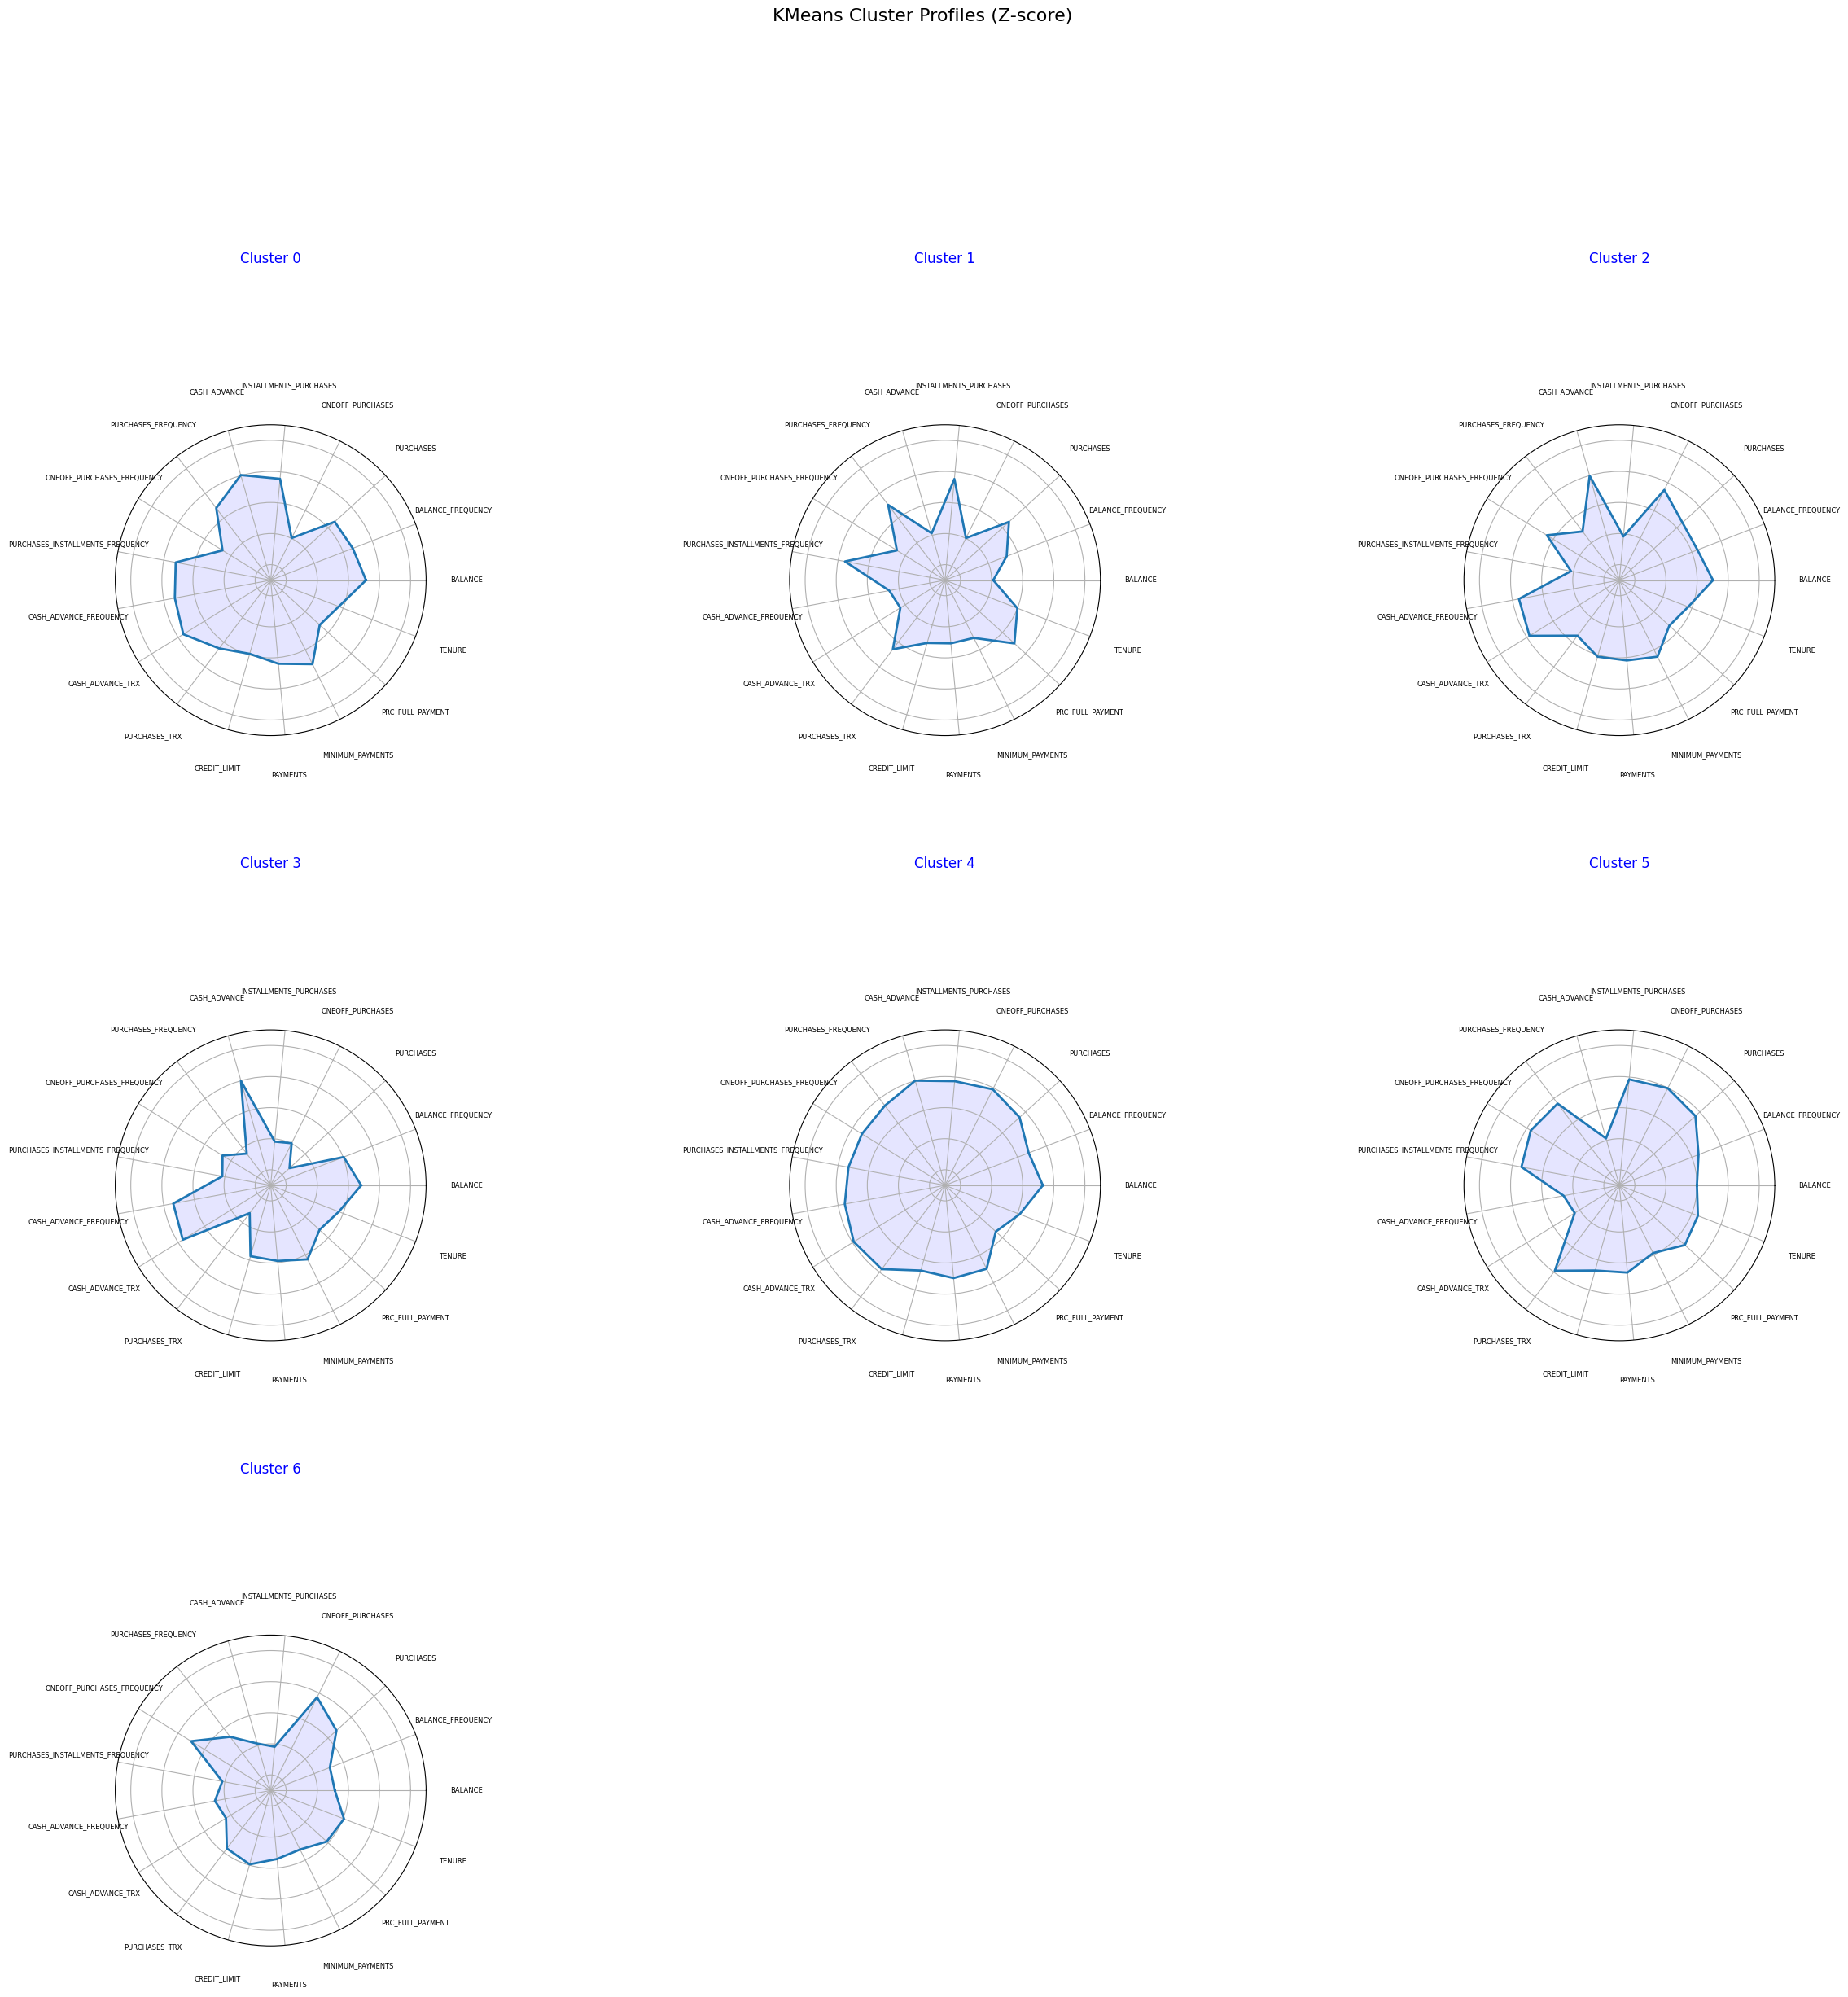

In [62]:
def plot_radar_chart(df_profile, title='Cluster Profile Radar Chart'):
    '''
    Generates a radar chart for a given DataFrame of cluster profiles.

    Args:
        df_profile (pd.DataFrame): DataFrame where index are clusters and columns are features (z-scores).
        title (str): Title for the overall set of radar charts.
    '''
    categories = list(df_profile.columns)
    N = len(categories)

    # What will be the angle of each axis in the plot?
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    # Determine optimal grid size for subplots
    num_clusters = len(df_profile)
    n_rows = int(np.ceil(num_clusters / 3)) # Max 3 columns
    n_cols = min(num_clusters, 3)

    fig, axes = plt.subplots(figsize=(25, 8 * n_rows), nrows=n_rows, ncols=n_cols, subplot_kw=dict(polar=True))
    axes = axes.flatten()

    # Plot each cluster
    for i, (cluster_label, row) in enumerate(df_profile.iterrows()):
        if i >= len(axes): # Ensure we don't go out of bounds if more clusters than subplots
            break

        values = row.values.flatten().tolist()
        values += values[:1]

        ax = axes[i]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster_label}')
        ax.fill(angles, values, 'b', alpha=0.1)
        ax.set_yticklabels([]) # Hide y-axis labels for cleaner look
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, color='black', size=6)
        ax.set_ylim(-2.5, 2.5) # Adjust y-limits based on expected z-score range
        ax.set_title(f'Cluster {cluster_label}', size=12, color='blue', y=1.5)
        ax.tick_params(axis='x', pad=25) # Increased padding to move labels further away from the chart

    # Remove empty subplots if there are fewer clusters than subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, size=16, color='black', y=1.05) # Main title for the entire figure
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()

# Call the function with your z_score_profile
plot_radar_chart(z_score_profile, title='KMeans Cluster Profiles (Z-score)')